# Isolation Forest

Isolation Forest (iForest) is an unsupervised machine learning algorithm specifically designed for anomaly detection. It works by identifying data points that are "few and different" — which is the core intuition behind anomalies.

**Core Idea:**
1. Builds random decision trees 
-  The algorithm starts by creating a set of isolation trees, typically hundreds or even thousands of them. These trees are similar to traditional decision trees, but with a key difference: they are not built to classify data points into specific categories. Instead, isolation trees aim to isolate individual data points by **repeatedly splitting the data based on randomly chosen features and split values.**
- Isolation trees introduce randomness at each node of the tree, a random feature from the dataset is selected. Then, a random split value is chosen within the range of that particular feature's values. This randomness helps ensure that anomalies, which tend to be distinct from the majority of data points, are not hidden within specific branches of the tree. 
2. Isolating Data Points 
- The data points are then directed down the branches of the isolation tree based on their feature values. If a data point's value for the chosen feature falls below the split value, it goes to the left branch. Otherwise, it goes to the right branch. This process continues recursively until the data point reaches a leaf node, which simply represents the isolated data point 
3. Calculate Anomaly Score: 
- Each data point is evaluated through all the isolation trees in the forest. For each tree, the path length (number of splits) required to isolate the data point is recorded. An anomaly score is then calculated for each data point by averaging the path lengths across all the isolation trees in the forest.
4. Identifying Anomalies: 
- Data points with shorter average path lengths are considered more likely to be anomalies. This is because they were easier to isolate, suggesting they deviate significantly from the bulk of the data. In contrast, normal points share more similarities with each other, lie within dense regions, and take more splits to isolate.


In [1]:
# Import libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
import optuna
import seaborn as sns

from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import precision_recall_curve, auc
from sklearn.metrics import average_precision_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import torch
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torchvision.datasets.folder import default_loader

/opt/anaconda3/envs/mads-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Part 1: Hazelnut Dataset

### Step 1.1: Feature Extraction Setup
Features are extracted using a pretrained CNN called Resnet 18 for efficiency.

In [2]:
# Extract features using pretrained CNN Resnet 18
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet18(pretrained=True)
model = torch.nn.Sequential(*list(model.children())[:-1])  # Extract features from the Global Average Pooling layer
model.eval().to(device)

transform = transforms.Compose([
    transforms.Resize((224, 224)),   # Resized to 224 x 224
    transforms.ToTensor(),   # Normalization divided by 255 implicitly
])

def extract_deep_features(img_paths):
    features = []
    for path in tqdm(img_paths, desc="Extracting features"):
        img = default_loader(path)
        img = transform(img).unsqueeze(0).to(device)
        with torch.no_grad():
            feat = model(img).squeeze().cpu().numpy()
        features.append(feat)
    return features

/opt/anaconda3/envs/mads-env/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/anaconda3/envs/mads-env/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


### Step 1.2: Load Train Features (good images only)

In [3]:
# Load train features or the good images only
train_dir = 'mvtec_anomaly_detection/hazelnut/train'
train_good_dir = os.path.join(train_dir, 'good')
train_paths = [os.path.join(train_good_dir, f) for f in os.listdir(train_good_dir) if f.endswith('.png')]
train_features = extract_deep_features(train_paths)
train_features = np.array(train_features)

Extracting features: 100%|██████████| 391/391 [00:27<00:00, 14.22it/s]


### Step 1.3: Load Test Features and Labels

In [4]:
# Load test features and labels
test_dir = 'mvtec_anomaly_detection/hazelnut/test'
test_features = []
test_labels = []  # 1 for normal, -1 for anomaly
test_classes = [] 
test_paths = []
img_paths = []

for subdir in os.listdir(test_dir):
    full_path = os.path.join(test_dir, subdir)
    label = 1 if subdir == 'good' else -1
    images = [os.path.join(full_path, f) for f in os.listdir(full_path) if f.endswith('.png')]
    feats = extract_deep_features(images)
    test_features.extend(feats)
    test_labels.extend([label] * len(images))
    test_classes.extend([subdir] * len(images))  # track the real class (cut, crack, etc.)
    test_paths.extend(images)
    img_paths.extend(images)

test_features = np.array(test_features)
test_labels = np.array(test_labels)
test_classes = np.array(test_classes)

Extracting features: 100%|██████████| 18/18 [00:01<00:00, 15.21it/s]


### Step 1.4: Predict and Evaluate

#### Step 1.4.1: Manual Hyperparameter Tuning
Manual hyperparameter tuning is used at first to test the range of parameters that can yield acceptable results (especially Recall, F1 Score, and PR AUC) for the Isolation Forest.

In [5]:
# Define true labels in test dataset
# If image score is -1, then it is an anomaly, then treat as positive class 1
# If image score is 1, then it is normal, then treat as negative class 0
true_bin = [1 if y == -1 else 0 for y in test_labels]

# Define Isolation Forest function
def evaluate_isolation_forest(params, model_name="Model"):
    clf = IsolationForest(**params, random_state=42)
    clf.fit(train_features)

    preds = clf.predict(test_features)
    preds_bin = [1 if p == -1 else 0 for p in preds]

    # Negate decision function because anomaly is the positive class, and metrics assume higher score as positive class
    scores = -clf.decision_function(test_features)  

    # Compute PR-AUC
    precision, recall, _ = precision_recall_curve(true_bin, scores)
    pr_auc = auc(recall, precision)

    return {
        'Model': model_name,
        'Accuracy': accuracy_score(true_bin, preds_bin),
        'Precision': precision_score(true_bin, preds_bin, zero_division=0),
        'Recall': recall_score(true_bin, preds_bin),
        'F1 Score': f1_score(true_bin, preds_bin),
        'ROC AUC': roc_auc_score(true_bin, scores),
        'PR AUC': pr_auc,
        'Params': params,
        'Scores': scores,
        'Model Object': clf
    }

# Manually evaluate multiple parameter sets
results = []

param_list = [
    {'n_estimators': 100, 'max_samples': 0.7, 'contamination': 0.05, 'max_features': 1.0},
    {'n_estimators': 200, 'max_samples': 0.7, 'contamination': 0.02, 'max_features': 1.0},
    {'n_estimators': 200, 'max_samples': 0.8, 'contamination': 0.05, 'max_features': 0.8},
    {'n_estimators': 200, 'max_samples': 0.8, 'contamination': 0.01, 'max_features': 1.0},
    {'n_estimators': 300, 'max_samples': 0.6, 'contamination': 0.02, 'max_features': 0.6},
]

for i, params in enumerate(param_list, 1):
    result = evaluate_isolation_forest(params, model_name=f"Model {i}")
    results.append(result)

hazelnut_results_df = pd.DataFrame(results)
hazelnut_results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,PR AUC,Params,Scores,Model Object
0,Model 1,0.654545,0.970588,0.471429,0.634615,0.863214,0.924539,"{'n_estimators': 100, 'max_samples': 0.7, 'con...","[-0.010368171953325955, -0.04617333436332344, ...","(ExtraTreeRegressor(max_depth=9, max_features=..."
1,Model 2,0.609091,1.000000,0.385714,0.556701,0.882143,0.932983,"{'n_estimators': 200, 'max_samples': 0.7, 'con...","[-0.02810164602284798, -0.05102665746631013, 0...","(ExtraTreeRegressor(max_depth=9, max_features=..."
2,Model 3,0.709091,0.975000,0.557143,0.709091,0.896071,0.945840,"{'n_estimators': 200, 'max_samples': 0.8, 'con...","[-0.01809987992266282, -0.029778594765967836, ...","(ExtraTreeRegressor(max_depth=9, max_features=..."
3,Model 4,0.536364,1.000000,0.271429,0.426966,0.885000,0.938106,"{'n_estimators': 200, 'max_samples': 0.8, 'con...","[-0.05283854913266012, -0.06847583821784792, 0...","(ExtraTreeRegressor(max_depth=9, max_features=..."
4,Model 5,0.600000,1.000000,0.371429,0.541667,0.906071,0.949085,"{'n_estimators': 300, 'max_samples': 0.6, 'con...","[-0.04090684660321681, -0.051467959813767394, ...","(ExtraTreeRegressor(max_depth=8, max_features=..."


#### Step 1.4.2: Use Optuna (Bayesian Optimization) for Automatic Hyperparameter Tuning
We wanted to try out automating hyperparameter tuning and see if this leads to better results vs. manual hyperparameter tuning. Hence, we also used **Optuna**, which is a modern, open‑source framework for automated hyperparameter optimization. It implements Bayesian Optimization (and other strategies) to smartly search the space of model hyperparameters (e.g. number of trees, contamination rate, learning‑rate, regularization strength) in order to maximize (or minimize) some objective metric (e.g. PR AUC, accuracy, validation loss).

For more information, see: https://optuna.org/

In [6]:
# Use Bayesian Optimization
# Split test set into validation and hold‑out for fair tuning
X_val, X_hold, y_val, y_hold = train_test_split(
    test_features, test_labels, test_size=0.5,
    stratify=[1 if y == -1 else 0 for y in test_labels],
    random_state=42
)

# Define the objective to maximize F1 by sweeping threshold on negated decision_function
def objective(trial):
    # Hyperparameter range
    params = {
        'n_estimators':    trial.suggest_int('n_estimators', 100, 500),
        'max_samples':     trial.suggest_float('max_samples', 0.6, 1.0),
        'max_features':    trial.suggest_float('max_features', 0.5, 1.0),
        'contamination':   trial.suggest_float('contamination', 0.01, 0.2)
    }

    # Fit IsolationForest
    clf = IsolationForest(**params, random_state=42)
    clf.fit(train_features)

    # Get continuous anomaly‑scores (higher, more anomalous)
    scores = -clf.decision_function(X_val)

    # Find the threshold that gives the best F1 on validation
    y_true = [1 if y == -1 else 0 for y in y_val]            # 1=anomaly, 0=normal
    precisions, recalls, thresholds = precision_recall_curve(y_true, scores)
    f1s = 2 * (precisions * recalls) / (precisions + recalls + 1e-12)
    best_f1 = f1s.max()

    return best_f1

# Run optimization
sampler = optuna.samplers.TPESampler(seed=42)
study = optuna.create_study(direction='maximize', sampler=sampler)
study.optimize(objective, n_trials=30)

# Retrieve best hyperparameters
best_params = study.best_params

# Evaluate best model on the hold‑out set
best_result = evaluate_isolation_forest(best_params, model_name='Optuna Model')
results.append(best_result)

hazelnut_results_df2 = pd.DataFrame(results)
hazelnut_results_df2

[I 2025-05-06 16:10:08,456] A new study created in memory with name: no-name-c2fbf75e-cf35-4acc-8e16-b34759b4a6d0
[I 2025-05-06 16:10:08,835] Trial 0 finished with value: 0.8732394366192184 and parameters: {'n_estimators': 250, 'max_samples': 0.9802857225639665, 'max_features': 0.8659969709057025, 'contamination': 0.12374511199743696}. Best is trial 0 with value: 0.8732394366192184.
[I 2025-05-06 16:10:09,045] Trial 1 finished with value: 0.8860759493665951 and parameters: {'n_estimators': 162, 'max_samples': 0.662397808134481, 'max_features': 0.5290418060840998, 'contamination': 0.1745734676972377}. Best is trial 1 with value: 0.8860759493665951.
[I 2025-05-06 16:10:09,486] Trial 2 finished with value: 0.8749999999995078 and parameters: {'n_estimators': 341, 'max_samples': 0.8832290311184182, 'max_features': 0.5102922471479012, 'contamination': 0.19428287191077892}. Best is trial 1 with value: 0.8860759493665951.
[I 2025-05-06 16:10:10,055] Trial 3 finished with value: 0.8974358974354

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,PR AUC,Params,Scores,Model Object
0,Model 1,0.654545,0.970588,0.471429,0.634615,0.863214,0.924539,"{'n_estimators': 100, 'max_samples': 0.7, 'con...","[-0.010368171953325955, -0.04617333436332344, ...","(ExtraTreeRegressor(max_depth=9, max_features=..."
1,Model 2,0.609091,1.000000,0.385714,0.556701,0.882143,0.932983,"{'n_estimators': 200, 'max_samples': 0.7, 'con...","[-0.02810164602284798, -0.05102665746631013, 0...","(ExtraTreeRegressor(max_depth=9, max_features=..."
2,Model 3,0.709091,0.975000,0.557143,0.709091,0.896071,0.945840,"{'n_estimators': 200, 'max_samples': 0.8, 'con...","[-0.01809987992266282, -0.029778594765967836, ...","(ExtraTreeRegressor(max_depth=9, max_features=..."
3,Model 4,0.536364,1.000000,0.271429,0.426966,0.885000,0.938106,"{'n_estimators': 200, 'max_samples': 0.8, 'con...","[-0.05283854913266012, -0.06847583821784792, 0...","(ExtraTreeRegressor(max_depth=9, max_features=..."
4,Model 5,0.600000,1.000000,0.371429,0.541667,0.906071,0.949085,"{'n_estimators': 300, 'max_samples': 0.6, 'con...","[-0.04090684660321681, -0.051467959813767394, ...","(ExtraTreeRegressor(max_depth=8, max_features=..."
5,Optuna Model,0.681818,0.972973,0.514286,0.672897,0.910000,0.952110,"{'n_estimators': 433, 'max_samples': 0.6849356...","[-0.03016073999909996, -0.03504700205922978, 0...","(ExtraTreeRegressor(max_depth=9, max_features=..."


### Step 1.5: Visualize Metrics & Compare Models

Here, we visualize the metrics and compare among the different Isolation Forest Models. Although we computed a lot of metrics for this mini-project, we aim to give more importance to the ff. metrics: Precision, Recall, F1 Score, and PR-AUC, as these are considered as the best metrics for Anomaly Detection. 

- Precision is important as we aim to find which of the predicted anomalies are true anomalies. It answers the question: What proportion of the predicted anomalies are true?
- Recall is important as we aim to find as many real anomalies as possible (even if there are some false alarms). It answers the question: What proportion of true anomalies are identified?
- F1 Score is **the most important** to determine the balance between Precision and Recall. **This metric summarizes the full precision-recall tradeoff, which is exactly what matters when anomalies are rare--how many true defects you detect vs. how many false alerts you generate.**
- PR-AUC is important as we base the models on ranking the anomaly scores properly, especially when anomalies are very rare. This curve focuses on the positive (anomaly class). 

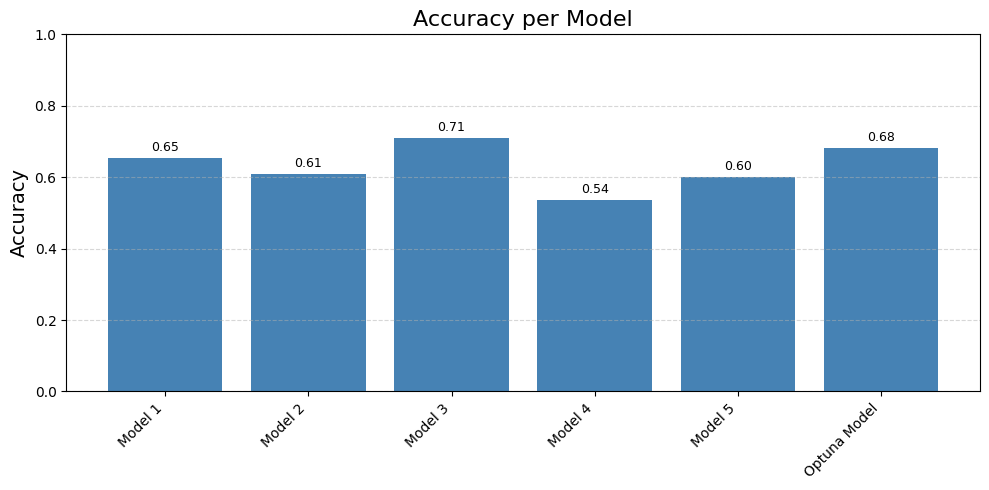

In [7]:
# Plot Accuracy of Models
# But this can be misleading because it hides all errors in the anomaly class - a model that calls everything normal has high accuracy
models = hazelnut_results_df2['Model']
accs   = hazelnut_results_df2['Accuracy']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(models, accs, color='steelblue')
ax.set_xticks(range(len(models)))
ax.set_xticklabels(models, rotation=45, ha='right', fontsize=10)
ax.bar_label(bars, labels=[f"{a:.2f}" for a in accs], padding=3, fontsize=9)

ax.set_title('Accuracy per Model', fontsize=16)
ax.set_ylabel('Accuracy', fontsize=14)
ax.set_ylim(0, 1)
ax.grid(True, axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


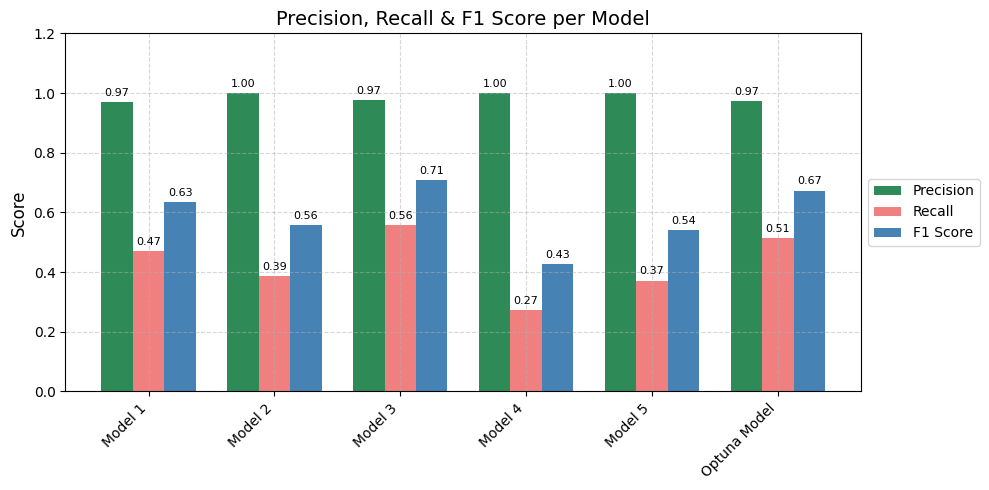

In [8]:
# Plot Precision, Recall, and F1 Score Per Model
x = np.arange(len(hazelnut_results_df2['Model']))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))

bars1 = ax.bar(x - width, hazelnut_results_df2['Precision'], width=width, label='Precision', color='seagreen')
bars2 = ax.bar(x, hazelnut_results_df2['Recall'], width=width, label='Recall', color='lightcoral')
bars3 = ax.bar(x + width, hazelnut_results_df2['F1 Score'], width=width, label='F1 Score', color='steelblue')

for bars in [bars1, bars2, bars3]:
    ax.bar_label(bars, labels=[f"{b.get_height():.2f}" for b in bars], padding=3, fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(hazelnut_results_df2['Model'], rotation=45, ha='right', fontsize=10)

ax.set_ylim(0, 1.2)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Precision, Recall & F1 Score per Model', fontsize=14)

ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))

plt.tight_layout()
plt.show()


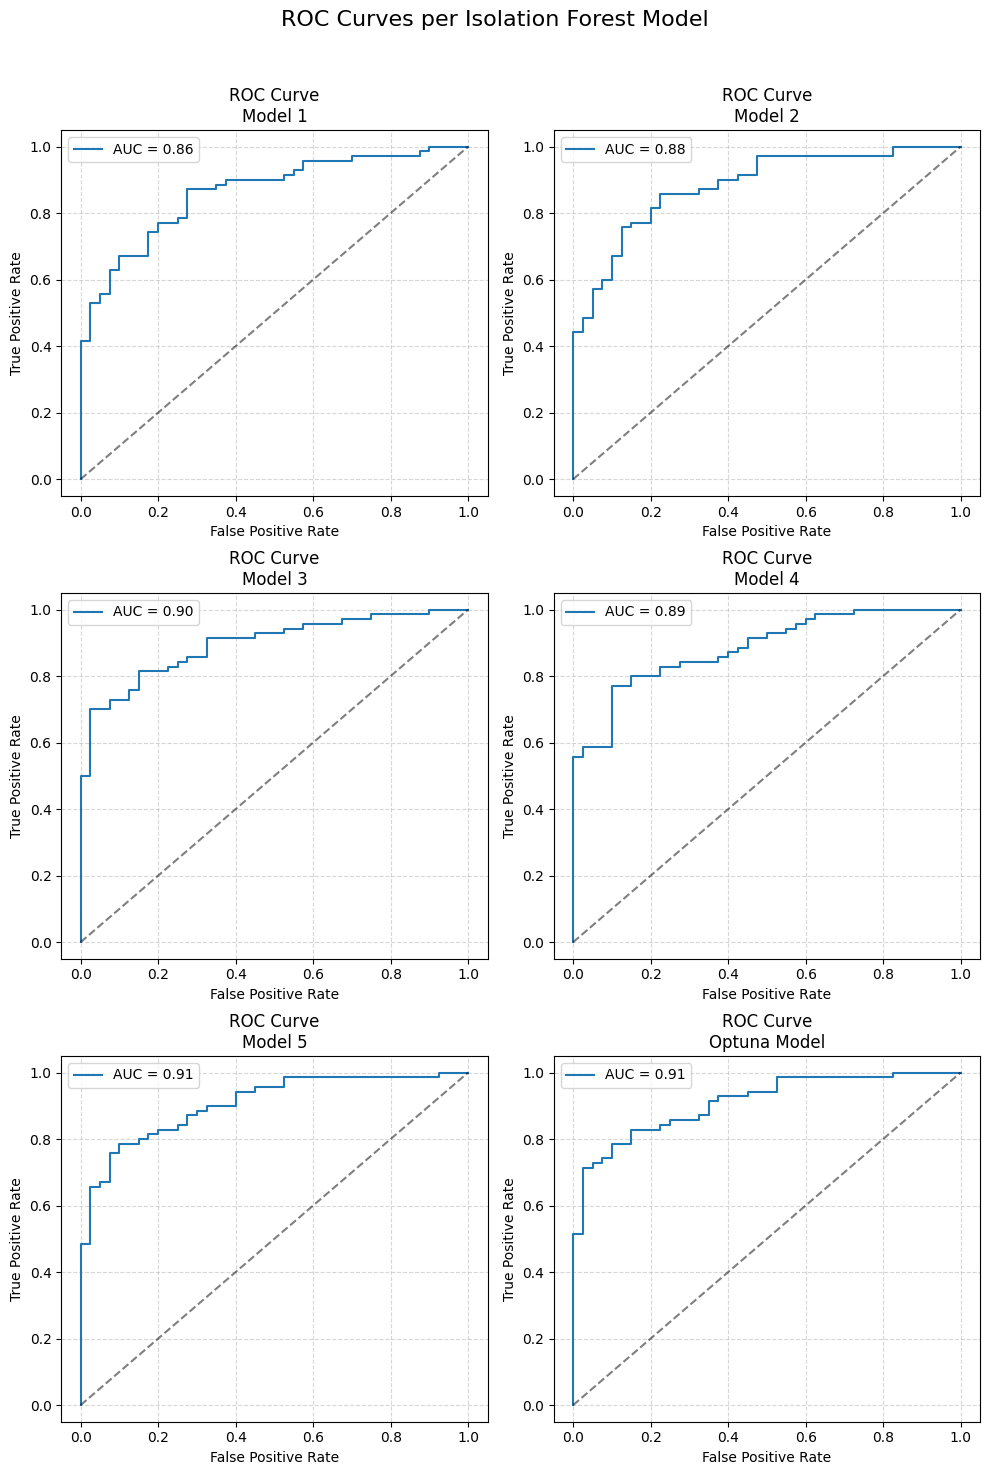

In [9]:
# Plot ROC Curve
# But this can be misleading because it will overstate performance when the good (negative) class dominates
num_models = len(hazelnut_results_df2)
n_cols = 2
n_rows = (num_models + 1) // n_cols

fig, axs = plt.subplots(n_rows, n_cols, figsize=(10, 5 * n_rows), sharey=False)
axs = axs.flatten()

for i, row in hazelnut_results_df2.iterrows():
    model_name = row['Model']
    scores = row['Scores']
    fpr, tpr, _ = roc_curve(true_bin, scores)
    auc_score = row['ROC AUC']
    
    ax = axs[i]
    ax.plot(fpr, tpr, label=f'AUC = {auc_score:.2f}')
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.5)
    ax.set_title(f'ROC Curve\n{model_name}', fontsize=12)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.5)

for j in range(i + 1, len(axs)):
    axs[j].axis('off')

plt.suptitle('ROC Curves per Isolation Forest Model', fontsize=16)
plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()

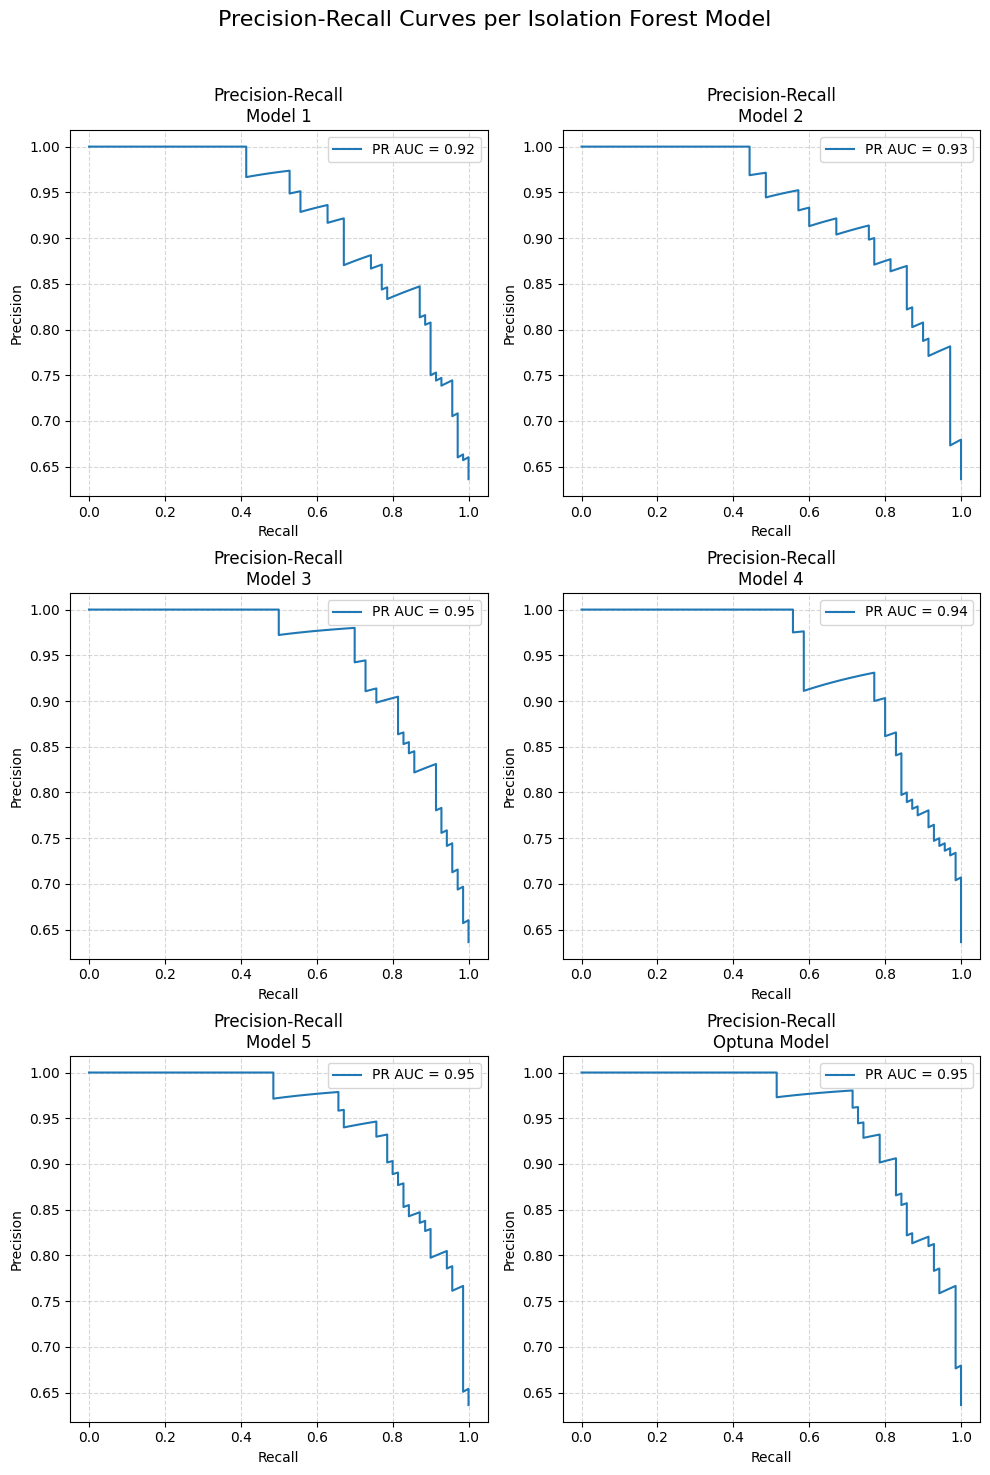

In [10]:
# Plot PR AUC Curve
# Best metric for Anomaly detection
fig, axs = plt.subplots(n_rows, n_cols, figsize=(10, 5 * n_rows), sharey=False)
axs = axs.flatten()

for i, row in hazelnut_results_df2.iterrows():
    model_name = row['Model']
    scores = row['Scores']
    precision, recall, _ = precision_recall_curve(true_bin, scores)
    pr_auc = row['PR AUC']
    
    ax = axs[i]
    ax.plot(recall, precision, label=f'PR AUC = {pr_auc:.2f}')
    ax.set_title(f'Precision-Recall\n{model_name}', fontsize=12)
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.5)

for j in range(i + 1, len(axs)):
    axs[j].axis('off')

plt.suptitle('Precision-Recall Curves per Isolation Forest Model', fontsize=16)
plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()

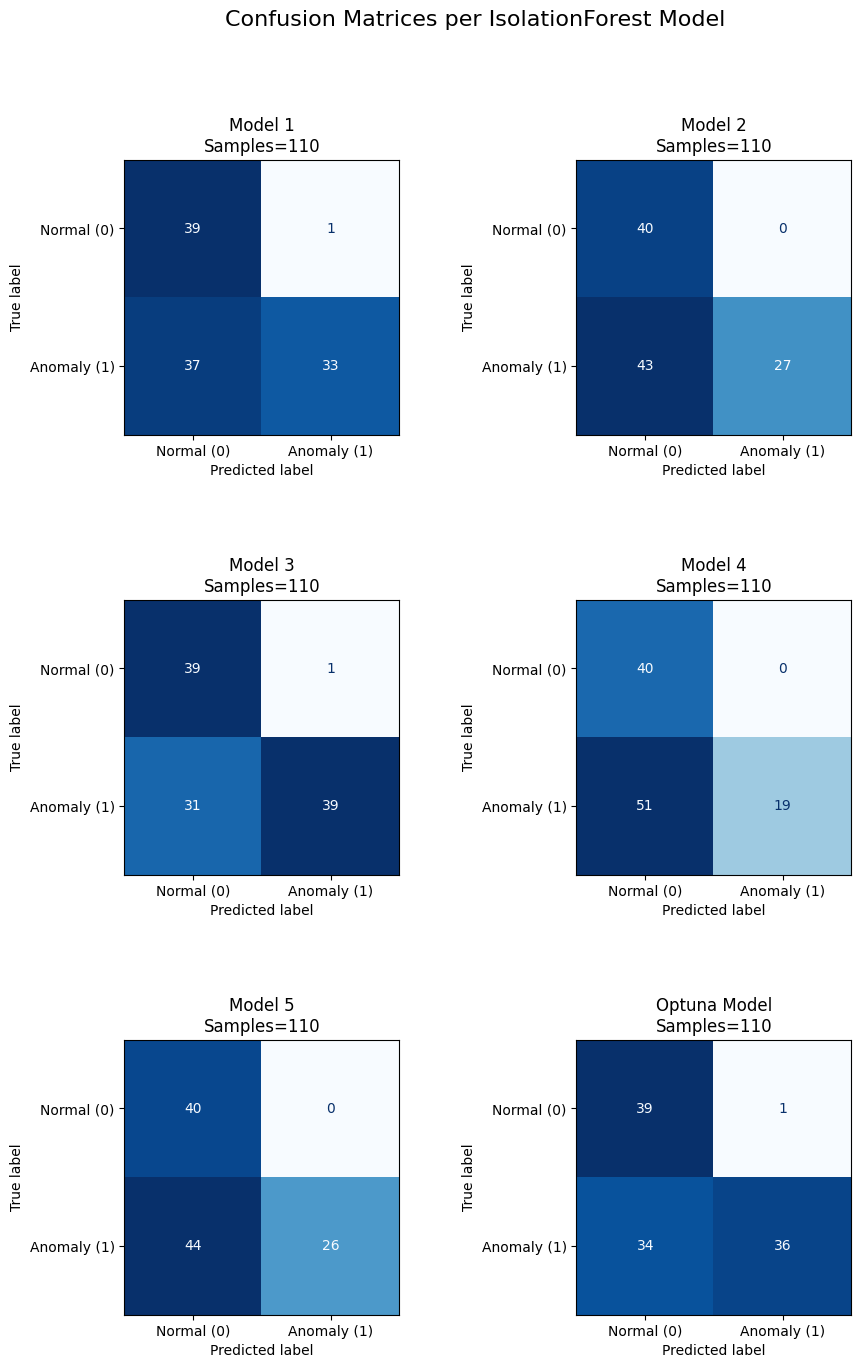

In [11]:
# Plot Confusion Matrix per Model
num_models = len(hazelnut_results_df2)
n_cols = 2
n_rows = (num_models + n_cols - 1) // n_cols

fig, axs = plt.subplots(n_rows, n_cols, 
                        figsize=(10, 5 * n_rows),
                        gridspec_kw={'wspace': 0.4, 'hspace': 0.6})
axs = axs.flatten()

for i, (_, row) in enumerate(hazelnut_results_df2.iterrows()):
    model_name = row['Model']
    scores     = np.asarray(row['Scores'])
    
    # Recompute binary preds: anomaly if score ≥ 0 (since we negated decision_function earlier)
    preds_bin = (scores >= 0).astype(int)
    
    cm = confusion_matrix(true_bin, preds_bin, labels=[0,1])
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Normal (0)", "Anomaly (1)"]
    )
    disp.plot(ax=axs[i], cmap='Blues', colorbar=False)
    axs[i].set_title(f"{model_name}\nSamples={len(true_bin)}")

for j in range(i+1, len(axs)):
    axs[j].axis('off')

plt.suptitle("Confusion Matrices per IsolationForest Model", fontsize=16)
plt.show()


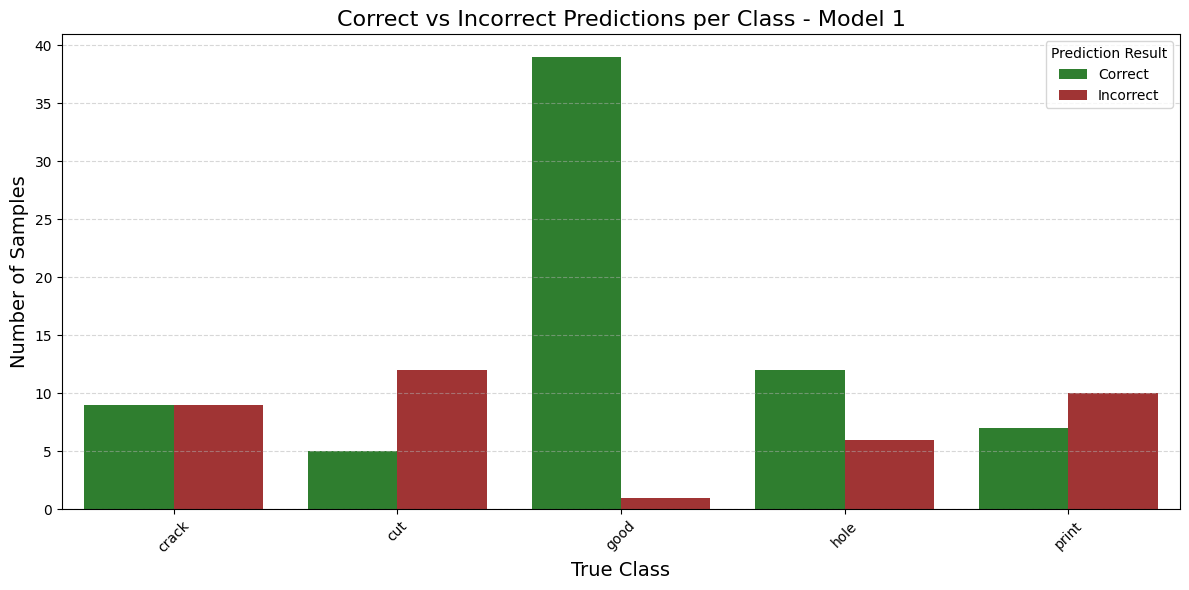

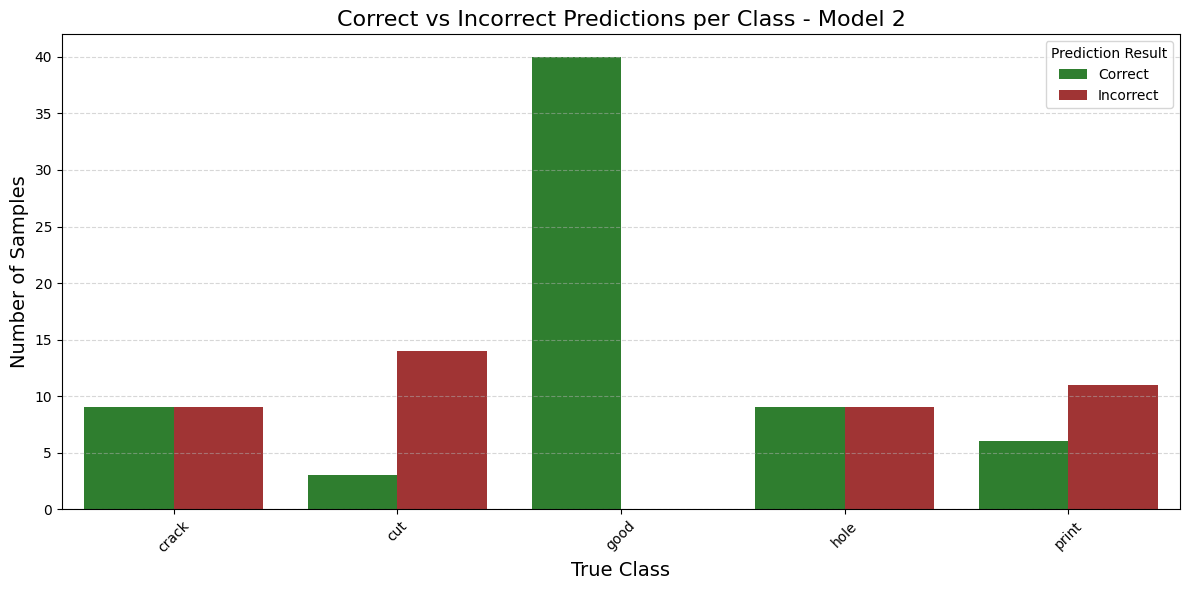

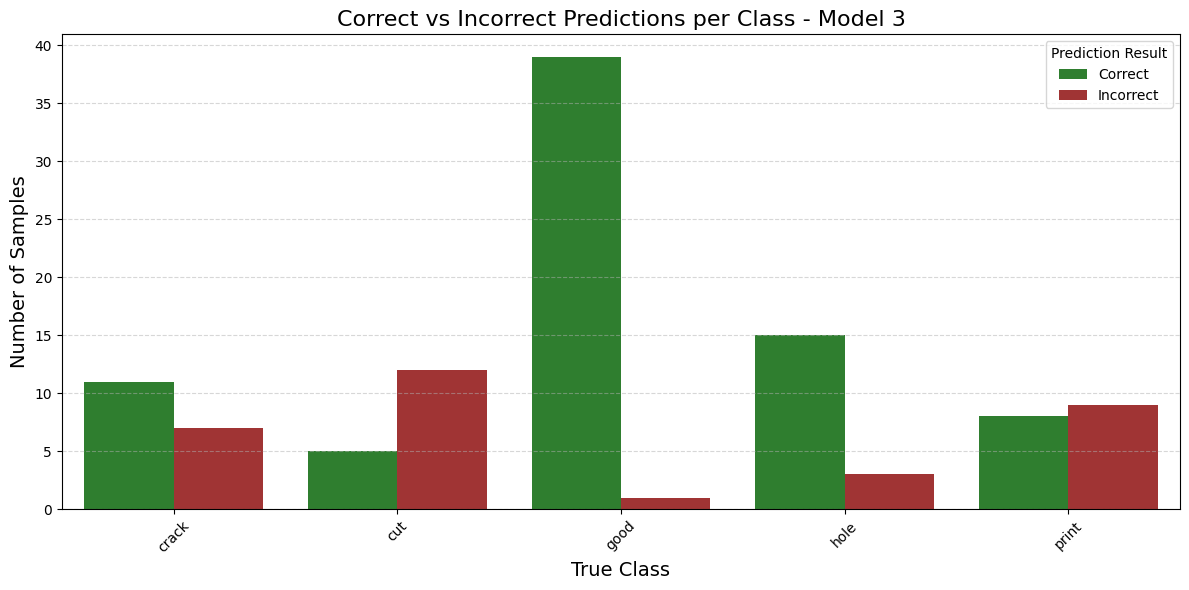

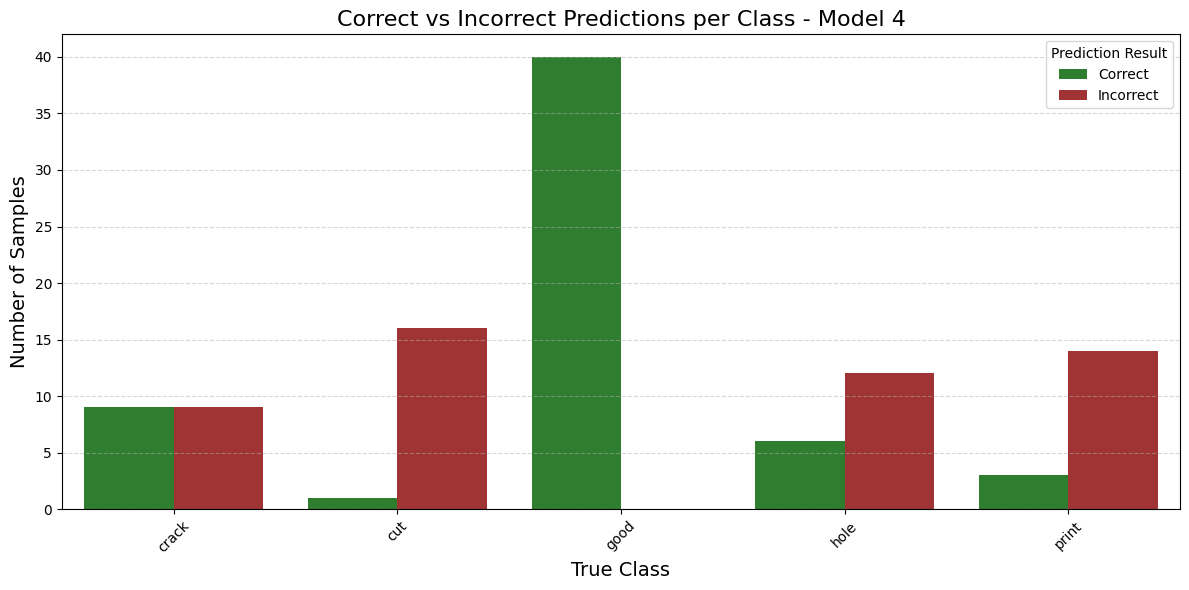

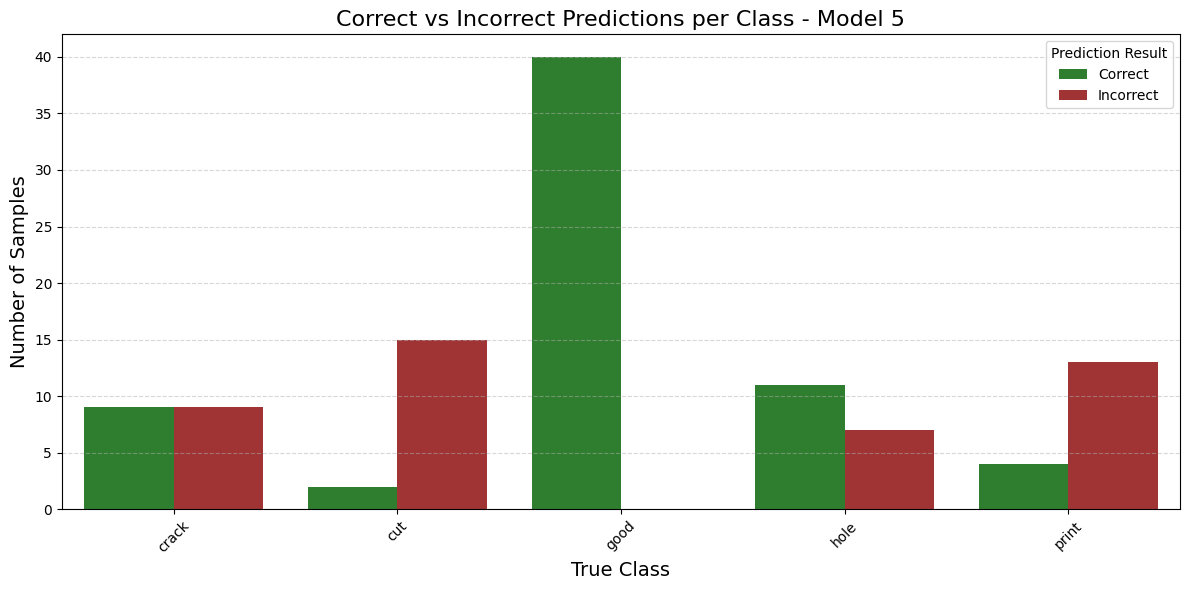

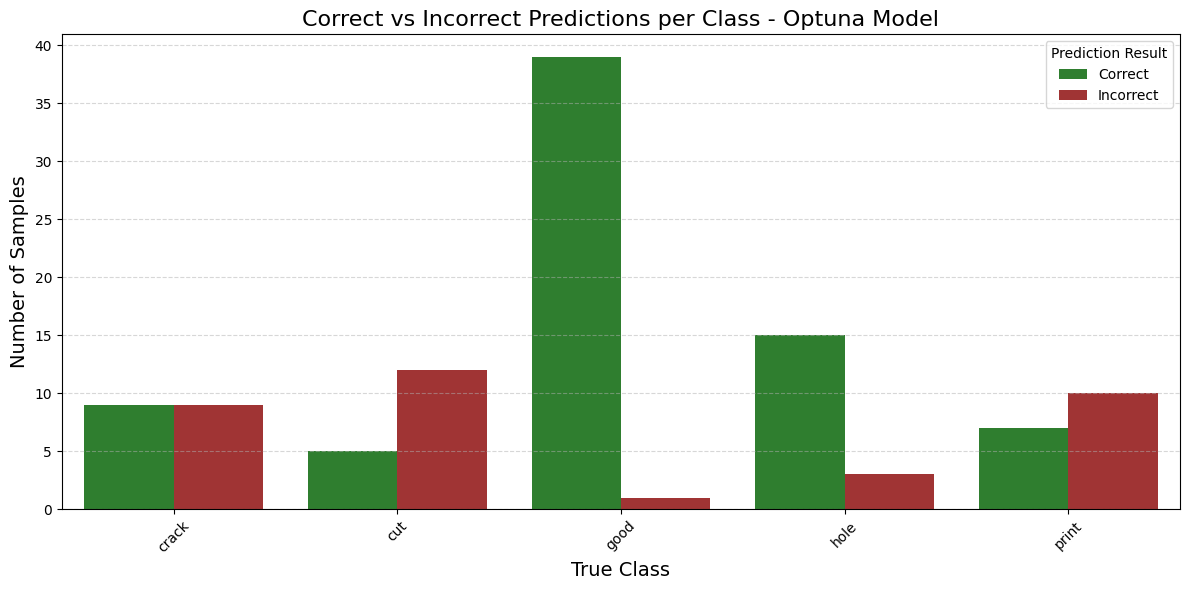

In [12]:
# Plot Correct and Incorrect Scores per Model
# Define normal and anomalous classes
normal_classes = ['good']
anomalous_classes = ['cut', 'crack', 'hole', 'print']

for idx, row in hazelnut_results_df2.iterrows():
    model_name = row['Model']
    scores = row['Scores']
    
    # Since scores = –decision_function,
    #  scores ≥ 0  means decision_function ≤ 0 ⇒ anomaly
    #  scores <  0  means decision_function >  0 ⇒ normal
    preds = np.array([-1 if s >= 0 else 1 for s in scores])
    
    # Build results DataFrame
    model_results = pd.DataFrame({
        'Image_Path': img_paths,
        'True_Class': [os.path.basename(os.path.dirname(p)) for p in img_paths],
        'Prediction': preds
    })

    # Map true labels
    model_results['True_Label'] = model_results['True_Class'].apply(
        lambda x: 1 if x in normal_classes else -1
    )

    # Determine correctness
    model_results['Correct'] = model_results['Prediction'] == model_results['True_Label']
    model_results['Correct_Label'] = model_results['Correct'].map({True: 'Correct', False: 'Incorrect'})

    grouped_counts = model_results.groupby(['True_Class', 'Correct_Label']).size().reset_index(name='Count')

    plt.figure(figsize=(12, 6))
    sns.barplot(data=grouped_counts, x='True_Class', y='Count', hue='Correct_Label', palette=['forestgreen','firebrick'])
    plt.title(f'Correct vs Incorrect Predictions per Class - {model_name}', fontsize=16)
    plt.xlabel('True Class', fontsize=14)
    plt.ylabel('Number of Samples', fontsize=14)
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.legend(title='Prediction Result')
    plt.tight_layout()
    plt.show()


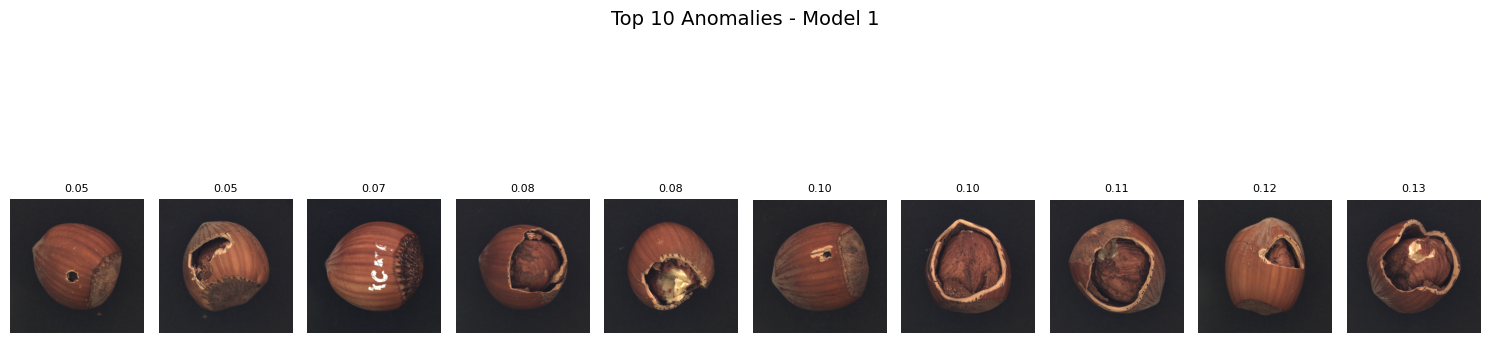

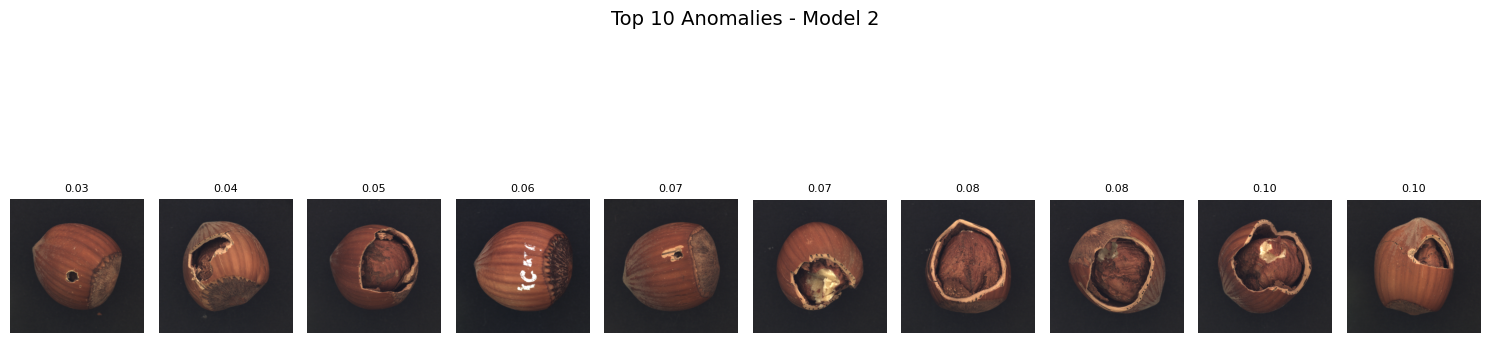

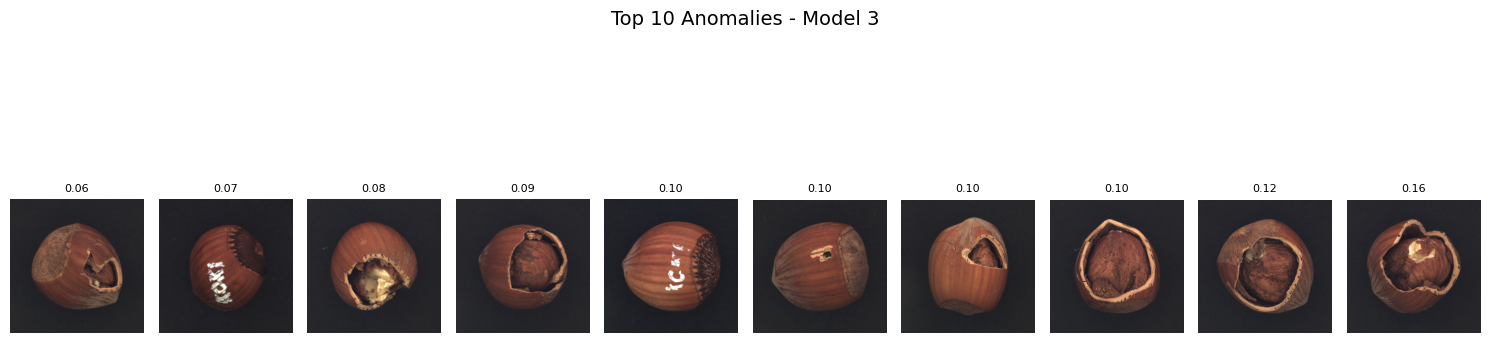

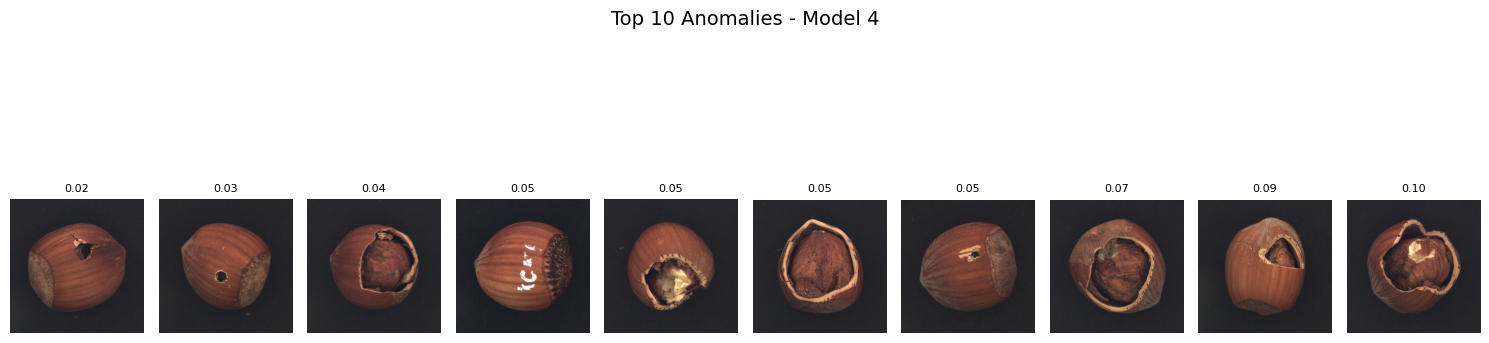

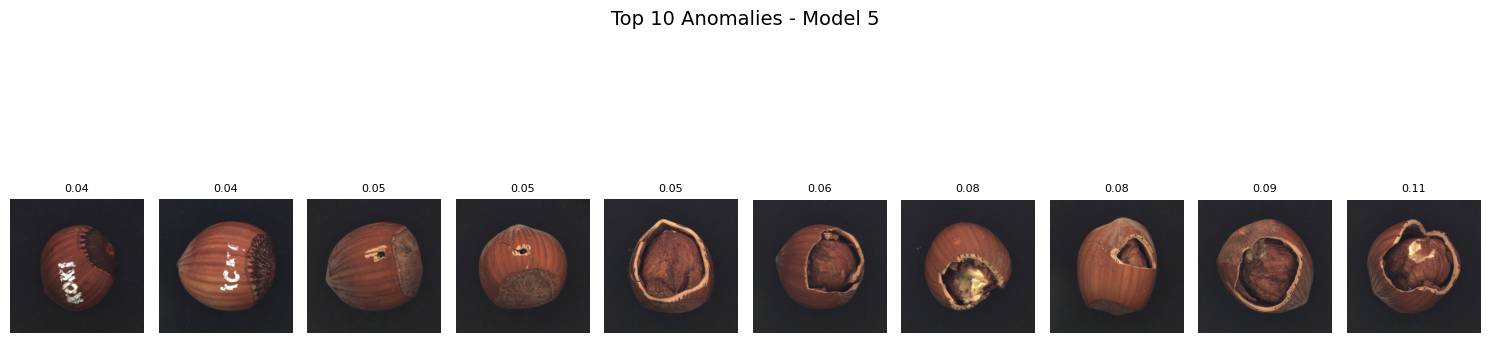

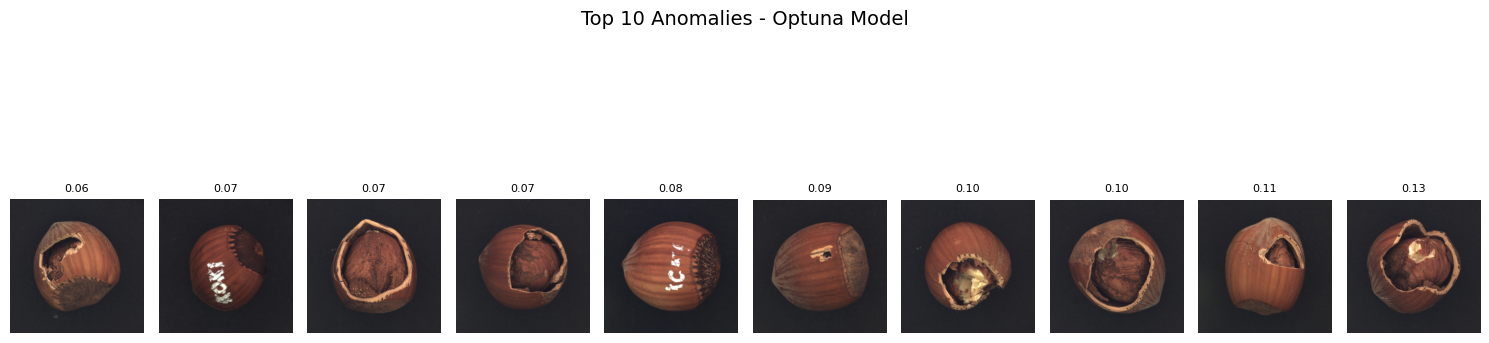

In [13]:
# Plot the Top Anomalies per Model
def plot_top_anomalies(model_name, scores, image_paths, top_n=10):

    # Get indices of the highest scores (most anomalous)
    top_indices = np.argsort(scores)[-top_n:]
    top_images = [image_paths[i] for i in top_indices]
    top_scores = [scores[i] for i in top_indices]

    plt.figure(figsize=(15, 5))
    for idx, (img_path, score) in enumerate(zip(top_images, top_scores)):
        img = Image.open(img_path)
        plt.subplot(1, top_n, idx + 1)
        plt.imshow(img)
        plt.title(f"{score:.2f}", fontsize=8)
        plt.axis("off")
    plt.suptitle(f"Top {top_n} Anomalies - {model_name}", fontsize=14)
    plt.tight_layout()
    plt.show()

# Loop over all evaluated models in results dataframe
for idx, row in hazelnut_results_df2.iterrows():
    model_name = row['Model']
    scores = row['Scores']
    
    plot_top_anomalies(model_name, scores, img_paths, top_n=10)


**Key takeaways for Hazelnut Dataset:**

1) Moderate anomaly detection capability
- The Isolation Forest models consistently achieved moderately strong performance, with the best model (Model 3) having achieved an F1 score of 0.71.
- This indicates the models are moderately effective at ranking anomalies higher than normal instances across the board, with a few misses.

2) Imbalanced PR trade-off​
- The models showed almost perfect precision, meaning they produced zero false alarms for normal images.
- However, this came at the cost of low recall—they missed over half of the true anomalies.
- This suggests the model is very cautious in flagging anomalies, potentially overlooking subtle defects.
- One potential solution is to lower the decision threshold to capture more anomalies, improving recall at the expense of slightly more false positives.

3) Conservative: Flags clear anomalies only (Crack and Hole images)​
- The model reliably flagged clear and obvious defects like Crack and Hole images.
- However, it struggled with more subtle defects such as Print and Cut, likely due to their visual similarity to normal images or their weaker anomaly signals.
- This indicates a limitation in detecting less distinguishable anomalies using the current feature set or model sensitivity.

4) Minimal  model improvement with Optuna​
- Automated hyperparameter tuning via Optuna did not yield significant improvements over manually tuned models.
- In fact, manually selected parameters produced better recall, suggesting that domain knowledge and visual inspection might still play a critical role in tuning anomaly detectors.

​

## Part 2: Carpet Dataset
From the same MVTEC Anomaly Detection Dataset, we'll now use the Carpet dataset, which consists of more fine-grained images.

### Step 2.1: Load Train Features (good images only)

In [14]:
# Load train features or the good images only
train_dir = 'mvtec_anomaly_detection/carpet/train'
train_good_dir = os.path.join(train_dir, 'good')
train_paths = [os.path.join(train_good_dir, f) for f in os.listdir(train_good_dir) if f.endswith('.png')]
train_features = extract_deep_features(train_paths)

Extracting features: 100%|██████████| 280/280 [00:18<00:00, 15.23it/s]


### Step 2.2: Load Test Features and Labels

In [15]:
# Load test features and labels
test_dir = 'mvtec_anomaly_detection/carpet/test'
test_features = []
test_labels = []  # 1 for normal, -1 for anomaly
test_classes = [] 
test_paths = []
img_paths = []

for subdir in os.listdir(test_dir):
    full_path = os.path.join(test_dir, subdir)
    label = 1 if subdir == 'good' else -1
    images = [os.path.join(full_path, f) for f in os.listdir(full_path) if f.endswith('.png')]
    feats = extract_deep_features(images)
    test_features.extend(feats)
    test_labels.extend([label] * len(images))
    test_classes.extend([subdir] * len(images))  # track the real class
    test_paths.extend(images)
    img_paths.extend(images)

test_features = np.array(test_features)
test_labels = np.array(test_labels)
test_classes = np.array(test_classes)

Extracting features: 100%|██████████| 17/17 [00:01<00:00, 15.61it/s]


### Step 2.3: Predict & Evaluate using Isolation Forest

In [16]:
# Define true labels in test dataset
# If image score is -1, then it is an anomaly, then treat as positive class 1
# If image score is 1, then it is normal, then treat as negative class 0
true_bin = [1 if y == -1 else 0 for y in test_labels]

# Define Isolation Forest function
def evaluate_isolation_forest(params, model_name="Model"):
    clf = IsolationForest(**params, random_state=42)
    clf.fit(train_features)

    preds = clf.predict(test_features)
    preds_bin = [1 if p == -1 else 0 for p in preds]

    # Negate decision function because anomaly is the positive class, and metrics assume higher score as positive class
    scores = -clf.decision_function(test_features)  

    # Compute PR-AUC
    precision, recall, _ = precision_recall_curve(true_bin, scores)
    pr_auc = auc(recall, precision)

    return {
        'Model': model_name,
        'Accuracy': accuracy_score(true_bin, preds_bin),
        'Precision': precision_score(true_bin, preds_bin, zero_division=0),
        'Recall': recall_score(true_bin, preds_bin),
        'F1 Score': f1_score(true_bin, preds_bin),
        'ROC AUC': roc_auc_score(true_bin, scores),
        'PR AUC': pr_auc,
        'Params': params,
        'Scores': scores,
        'Model Object': clf
    }

# Manually evaluate multiple parameter sets
results = []

param_list = [
    {'n_estimators': 300, 'max_samples': 0.7, 'contamination': 0.01, 'max_features': 1.0},
    {'n_estimators': 400, 'max_samples': 'auto', 'contamination': 0.01, 'max_features': 0.7},
    {'n_estimators': 500, 'max_samples': 0.6, 'contamination': 0.01, 'max_features': 0.5},
    {'n_estimators': 800, 'max_samples': 0.8, 'contamination': 0.04, 'max_features': 0.6}, 
    {'n_estimators': 1200, 'max_samples': 0.6, 'contamination': 0.03, 'max_features': 0.8},
]

for i, params in enumerate(param_list, 1):
    result = evaluate_isolation_forest(params, model_name=f"Model {i}")
    results.append(result)

carpet_results_df = pd.DataFrame(results)
carpet_results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,PR AUC,Params,Scores,Model Object
0,Model 1,0.478632,0.937500,0.337079,0.495868,0.639647,0.872217,"{'n_estimators': 300, 'max_samples': 0.7, 'con...","[-0.03478547684098876, 0.06006835516716391, -0...","(ExtraTreeRegressor(max_depth=8, max_features=..."
1,Model 2,0.487179,0.967742,0.337079,0.500000,0.652889,0.876244,"{'n_estimators': 400, 'max_samples': 'auto', '...","[-0.04293655839277233, 0.036733027857492995, -...","(ExtraTreeRegressor(max_depth=8, max_features=..."
2,Model 3,0.487179,0.939394,0.348315,0.508197,0.660112,0.879680,"{'n_estimators': 500, 'max_samples': 0.6, 'con...","[-0.03526077730169763, 0.04019540878339467, -0...","(ExtraTreeRegressor(max_depth=8, max_features=..."
3,Model 4,0.572650,0.842105,0.539326,0.657534,0.658909,0.879529,"{'n_estimators': 800, 'max_samples': 0.8, 'con...","[0.0037730768216452937, 0.07921024758427553, -...","(ExtraTreeRegressor(max_depth=8, max_features=..."
4,Model 5,0.555556,0.836364,0.516854,0.638889,0.652488,0.875536,"{'n_estimators': 1200, 'max_samples': 0.6, 'co...","[0.004476100319944609, 0.08249635533880617, -0...","(ExtraTreeRegressor(max_depth=8, max_features=..."


In [17]:
# Use Bayesian Optimization
# Split test set into validation and hold‑out for fair tuning
X_val, X_hold, y_val, y_hold = train_test_split(
    test_features, test_labels, test_size=0.5,
    stratify=[1 if y == -1 else 0 for y in test_labels],
    random_state=42
)

# Define the objective to maximize F1 by sweeping threshold on negated decision_function
def objective(trial):
    # Hyperparameter range
    params = {
        'n_estimators':    trial.suggest_int('n_estimators', 300, 1200),
        'max_samples':     trial.suggest_float('max_samples', 0.6, 1.0),
        'max_features':    trial.suggest_float('max_features', 0.5, 1.0),
        'contamination':   trial.suggest_float('contamination', 0.01, 0.2)
    }

    # Fit IsolationForest
    clf = IsolationForest(**params, random_state=42)
    clf.fit(train_features)

    # Get continuous anomaly‑scores (higher, more anomalous)
    scores = -clf.decision_function(X_val)

    # Find the threshold that gives the best F1 on validation
    y_true = [1 if y == -1 else 0 for y in y_val]            # 1=anomaly, 0=normal
    precisions, recalls, thresholds = precision_recall_curve(y_true, scores)
    f1s = 2 * (precisions * recalls) / (precisions + recalls + 1e-12)
    best_f1 = f1s.max()

    return best_f1

# Run optimization
sampler = optuna.samplers.TPESampler(seed=42)
study = optuna.create_study(direction='maximize', sampler=sampler)
study.optimize(objective, n_trials=30)

# Retrieve best hyperparameters
best_params = study.best_params

# Evaluate best model on the hold‑out set
best_result = evaluate_isolation_forest(best_params, model_name='Optuna Model')
results.append(best_result)

carpet_results_df2 = pd.DataFrame(results)
carpet_results_df2

[I 2025-05-06 16:11:00,324] A new study created in memory with name: no-name-f0f7aed6-7a6c-4276-8e21-23d9ee39f5fc
[I 2025-05-06 16:11:01,178] Trial 0 finished with value: 0.862745098038725 and parameters: {'n_estimators': 637, 'max_samples': 0.9802857225639665, 'max_features': 0.8659969709057025, 'contamination': 0.12374511199743696}. Best is trial 0 with value: 0.862745098038725.
[I 2025-05-06 16:11:01,696] Trial 1 finished with value: 0.862745098038725 and parameters: {'n_estimators': 440, 'max_samples': 0.662397808134481, 'max_features': 0.5290418060840998, 'contamination': 0.1745734676972377}. Best is trial 0 with value: 0.862745098038725.
[I 2025-05-06 16:11:02,681] Trial 2 finished with value: 0.862745098038725 and parameters: {'n_estimators': 841, 'max_samples': 0.8832290311184182, 'max_features': 0.5102922471479012, 'contamination': 0.19428287191077892}. Best is trial 0 with value: 0.862745098038725.
[I 2025-05-06 16:11:03,975] Trial 3 finished with value: 0.862745098038725 and

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,PR AUC,Params,Scores,Model Object
0,Model 1,0.478632,0.937500,0.337079,0.495868,0.639647,0.872217,"{'n_estimators': 300, 'max_samples': 0.7, 'con...","[-0.03478547684098876, 0.06006835516716391, -0...","(ExtraTreeRegressor(max_depth=8, max_features=..."
1,Model 2,0.487179,0.967742,0.337079,0.500000,0.652889,0.876244,"{'n_estimators': 400, 'max_samples': 'auto', '...","[-0.04293655839277233, 0.036733027857492995, -...","(ExtraTreeRegressor(max_depth=8, max_features=..."
2,Model 3,0.487179,0.939394,0.348315,0.508197,0.660112,0.879680,"{'n_estimators': 500, 'max_samples': 0.6, 'con...","[-0.03526077730169763, 0.04019540878339467, -0...","(ExtraTreeRegressor(max_depth=8, max_features=..."
3,Model 4,0.572650,0.842105,0.539326,0.657534,0.658909,0.879529,"{'n_estimators': 800, 'max_samples': 0.8, 'con...","[0.0037730768216452937, 0.07921024758427553, -...","(ExtraTreeRegressor(max_depth=8, max_features=..."
4,Model 5,0.555556,0.836364,0.516854,0.638889,0.652488,0.875536,"{'n_estimators': 1200, 'max_samples': 0.6, 'co...","[0.004476100319944609, 0.08249635533880617, -0...","(ExtraTreeRegressor(max_depth=8, max_features=..."
5,Optuna Model,0.623932,0.808219,0.662921,0.728395,0.670144,0.884401,"{'n_estimators': 637, 'max_samples': 0.9802857...","[0.03390559502166063, 0.11033891973849536, -0....","(ExtraTreeRegressor(max_depth=9, max_features=..."


### Step 2.4: Visualize Metrics & Compare Models

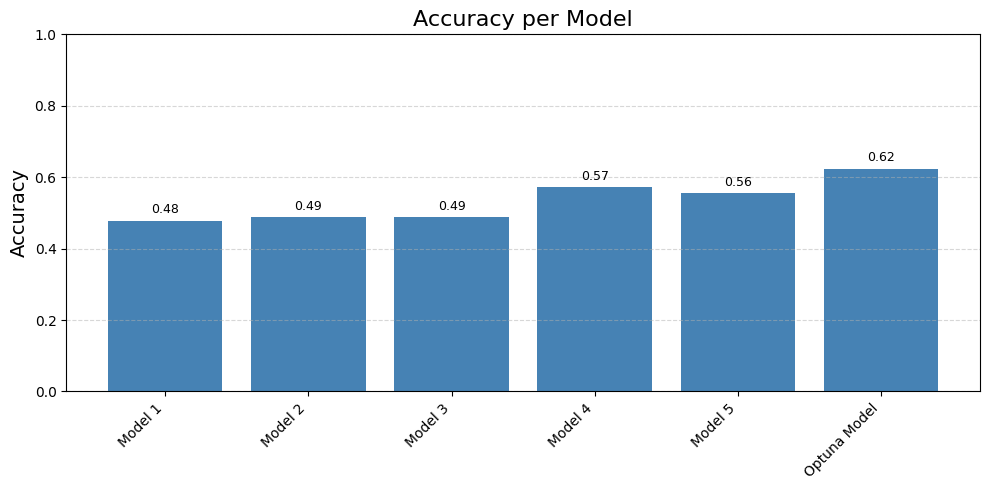

In [18]:
# Plot Accuracy of Models
# But this can be misleading because it hides all errors in the anomaly class - a model that calls everything normal has high accuracy
models = carpet_results_df2['Model']
accs   = carpet_results_df2['Accuracy']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(models, accs, color='steelblue')
ax.set_xticks(range(len(models)))
ax.set_xticklabels(models, rotation=45, ha='right', fontsize=10)
ax.bar_label(bars, labels=[f"{a:.2f}" for a in accs], padding=3, fontsize=9)

ax.set_title('Accuracy per Model', fontsize=16)
ax.set_ylabel('Accuracy', fontsize=14)
ax.set_ylim(0, 1)
ax.grid(True, axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


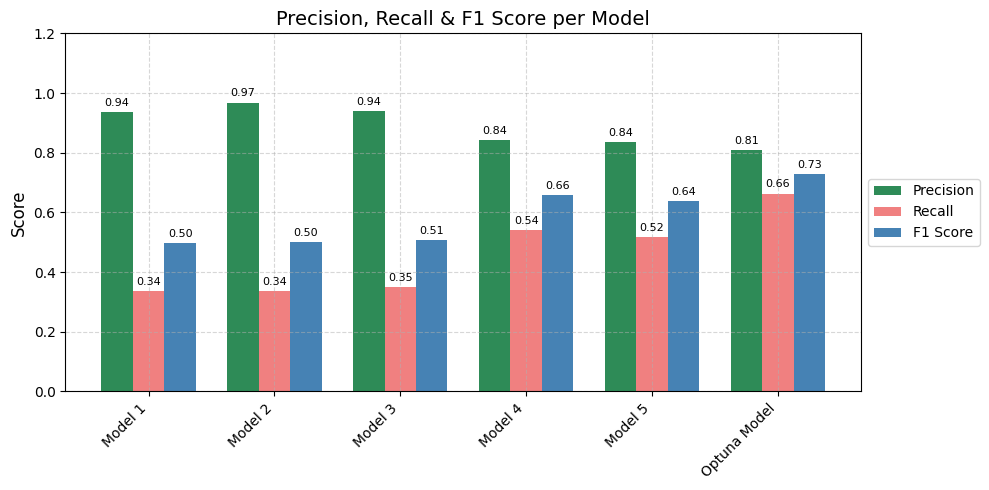

In [19]:
# Plot Precision, Recall, and F1 Score Per Model
x = np.arange(len(carpet_results_df2['Model']))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))

bars1 = ax.bar(x - width, carpet_results_df2['Precision'], width=width, label='Precision', color='seagreen')
bars2 = ax.bar(x, carpet_results_df2['Recall'], width=width, label='Recall', color='lightcoral')
bars3 = ax.bar(x + width, carpet_results_df2['F1 Score'], width=width, label='F1 Score', color='steelblue')

for bars in [bars1, bars2, bars3]:
    ax.bar_label(bars, labels=[f"{b.get_height():.2f}" for b in bars], padding=3, fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(carpet_results_df2['Model'], rotation=45, ha='right', fontsize=10)

ax.set_ylim(0, 1.2)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Precision, Recall & F1 Score per Model', fontsize=14)

ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))

plt.tight_layout()
plt.show()


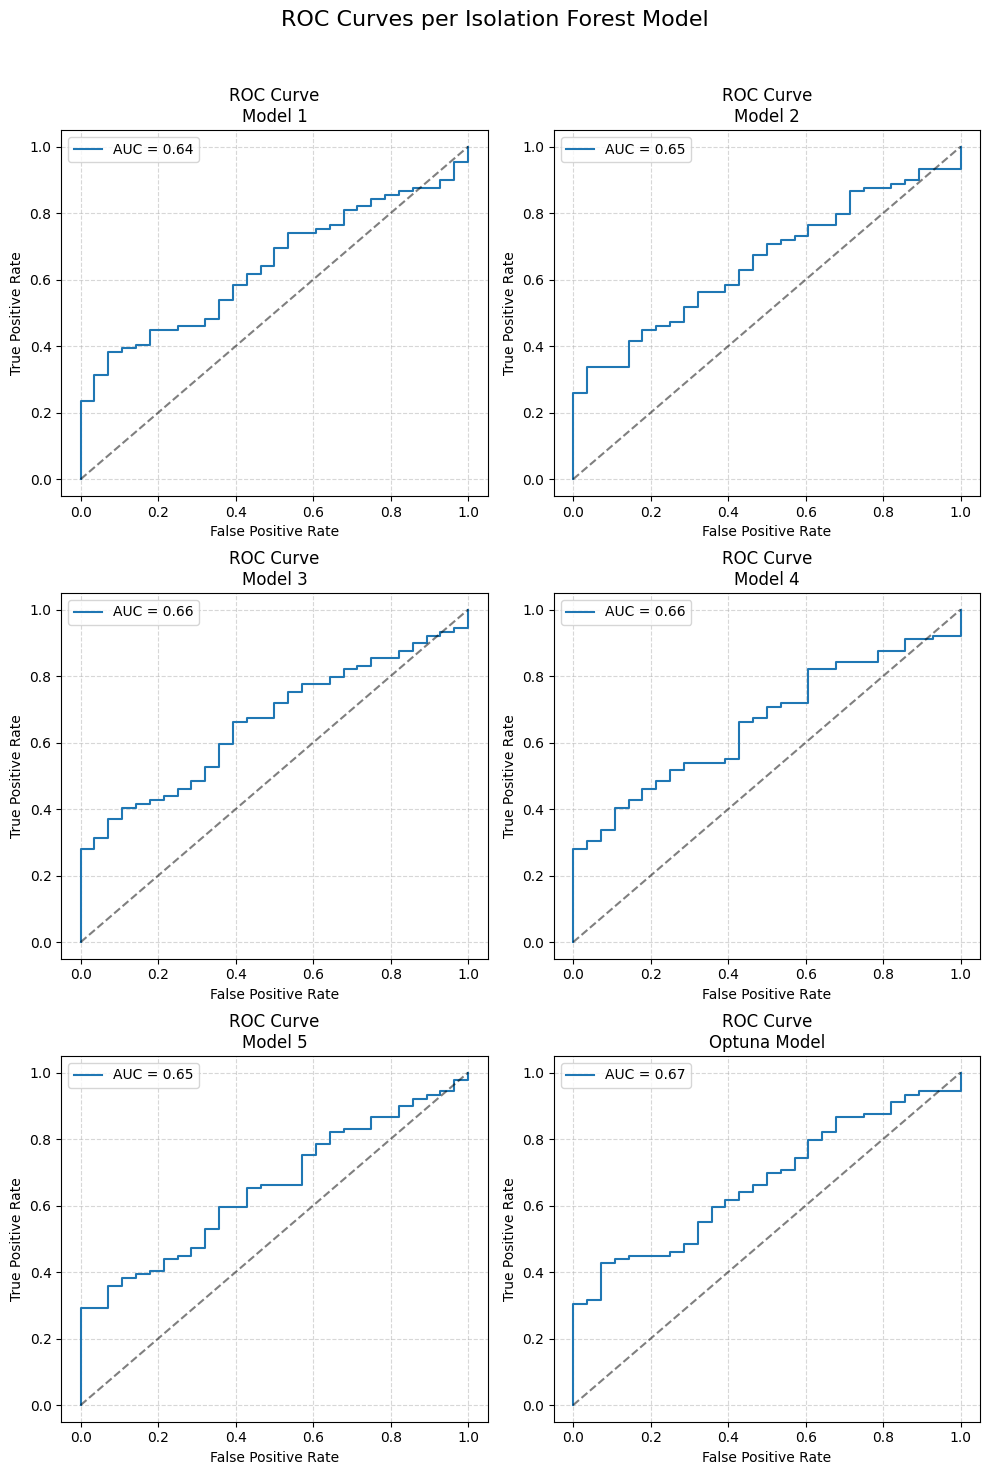

In [20]:
# Plot ROC Curve
# But this can be misleading because it will overstate performance when the good (negative) class dominates
num_models = len(carpet_results_df2)
n_cols = 2
n_rows = (num_models + 1) // n_cols

fig, axs = plt.subplots(n_rows, n_cols, figsize=(10, 5 * n_rows), sharey=False)
axs = axs.flatten()

for i, row in carpet_results_df2.iterrows():
    model_name = row['Model']
    scores = row['Scores']
    fpr, tpr, _ = roc_curve(true_bin, scores)
    auc_score = row['ROC AUC']
    
    ax = axs[i]
    ax.plot(fpr, tpr, label=f'AUC = {auc_score:.2f}')
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.5)
    ax.set_title(f'ROC Curve\n{model_name}', fontsize=12)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.5)

for j in range(i + 1, len(axs)):
    axs[j].axis('off')

plt.suptitle('ROC Curves per Isolation Forest Model', fontsize=16)
plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()

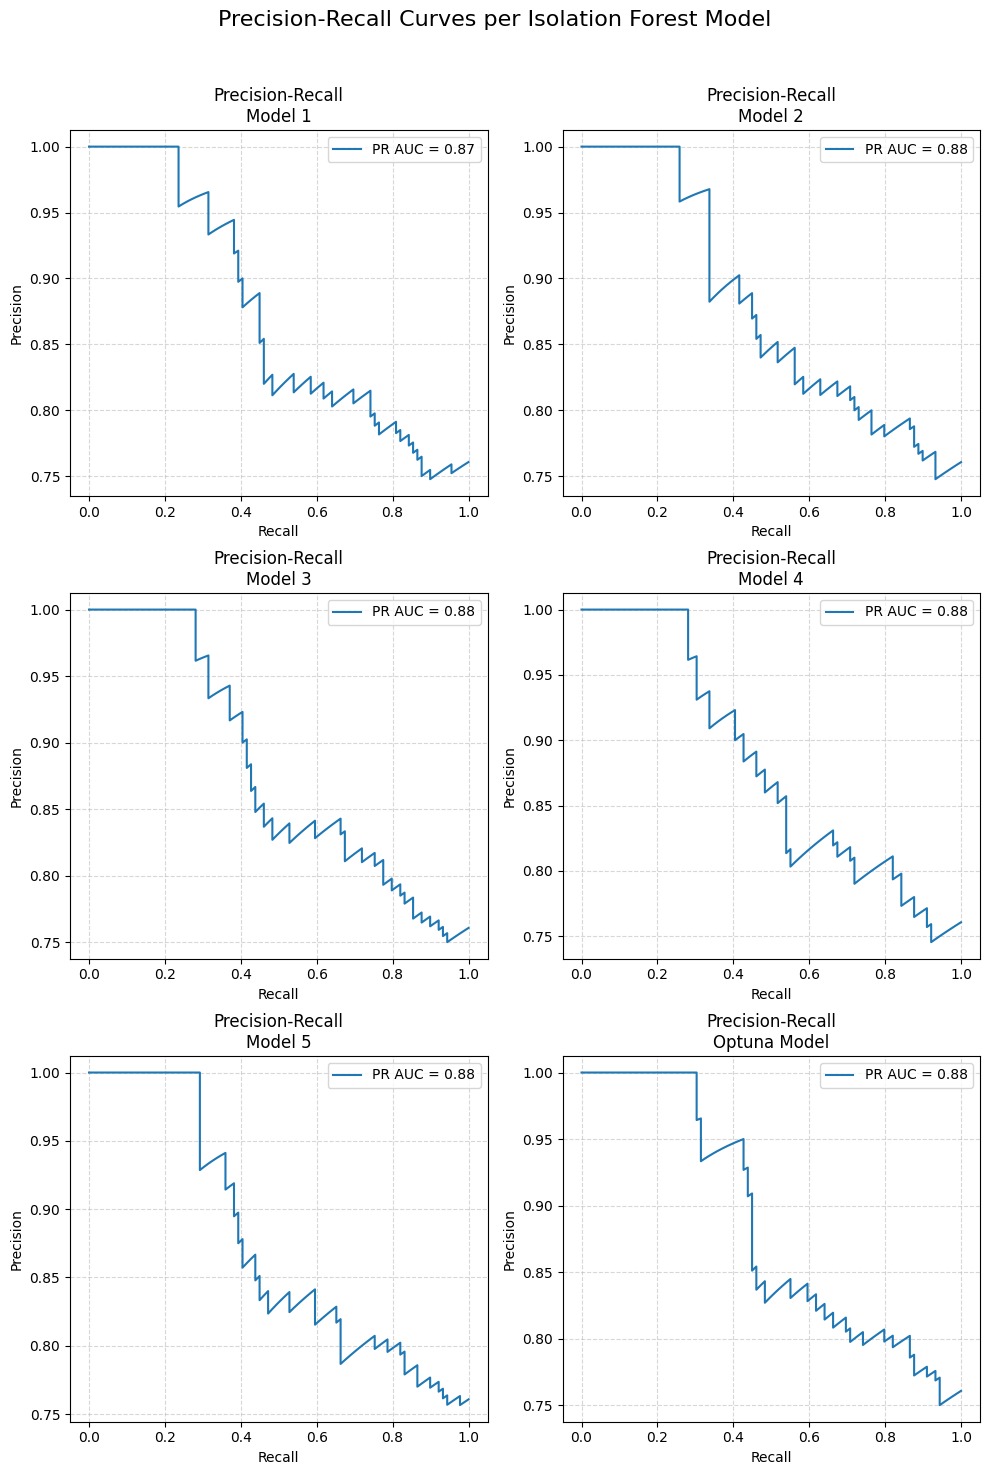

In [21]:
# Plot PR AUC Curve
# Best metric for Anomaly detection
fig, axs = plt.subplots(n_rows, n_cols, figsize=(10, 5 * n_rows), sharey=False)
axs = axs.flatten()

for i, row in carpet_results_df2.iterrows():
    model_name = row['Model']
    scores = row['Scores']
    precision, recall, _ = precision_recall_curve(true_bin, scores)
    pr_auc = row['PR AUC']
    
    ax = axs[i]
    ax.plot(recall, precision, label=f'PR AUC = {pr_auc:.2f}')
    ax.set_title(f'Precision-Recall\n{model_name}', fontsize=12)
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.5)

for j in range(i + 1, len(axs)):
    axs[j].axis('off')

plt.suptitle('Precision-Recall Curves per Isolation Forest Model', fontsize=16)
plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()

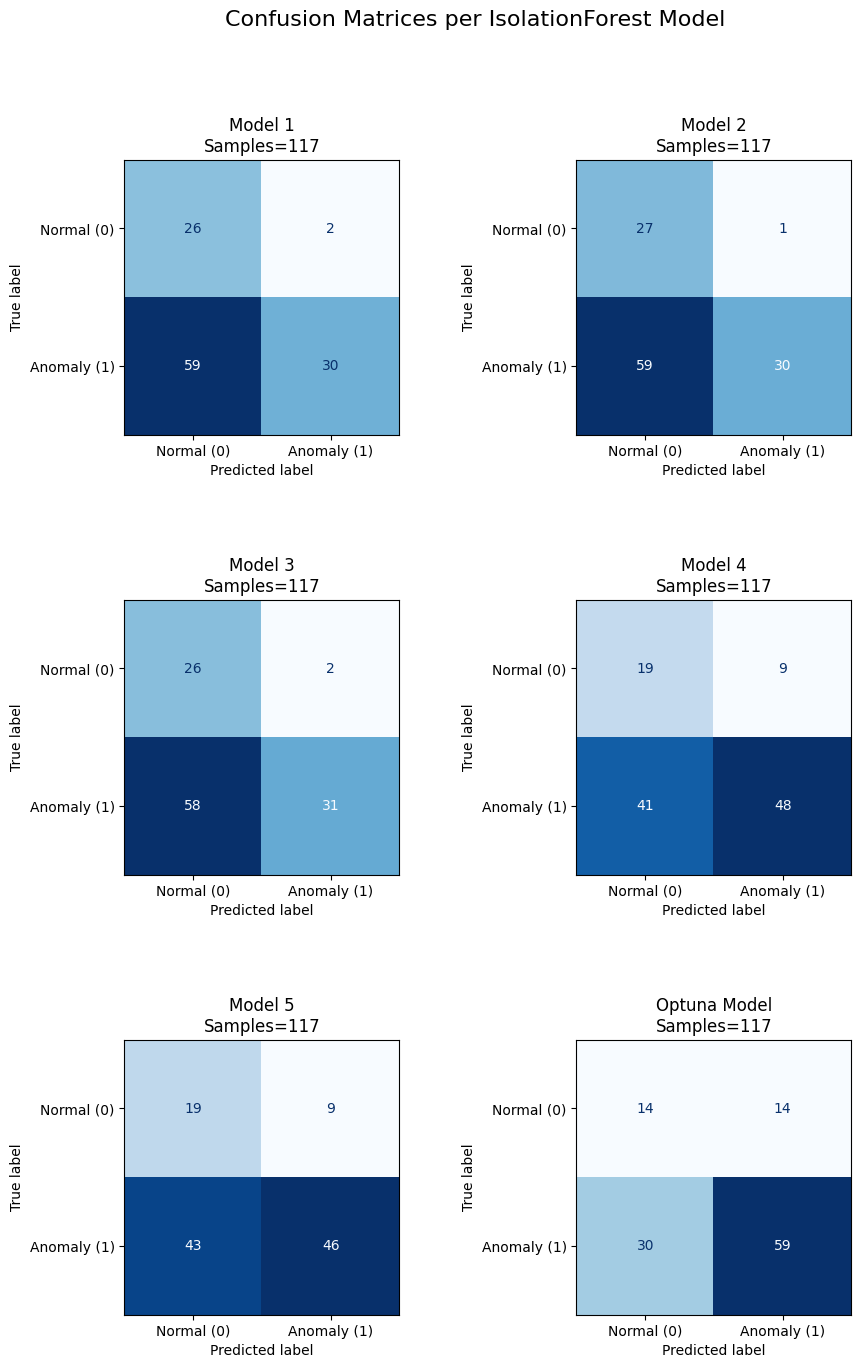

In [22]:
# Plot Confusion Matrix per Model
num_models = len(carpet_results_df2)
n_cols = 2
n_rows = (num_models + n_cols - 1) // n_cols

fig, axs = plt.subplots(n_rows, n_cols, 
                        figsize=(10, 5 * n_rows),
                        gridspec_kw={'wspace': 0.4, 'hspace': 0.6})
axs = axs.flatten()

for i, (_, row) in enumerate(carpet_results_df2.iterrows()):
    model_name = row['Model']
    scores     = np.asarray(row['Scores'])
    
    # Recompute binary preds: anomaly if score ≥ 0 (since we negated decision_function earlier)
    preds_bin = (scores >= 0).astype(int)
    
    cm = confusion_matrix(true_bin, preds_bin, labels=[0,1])
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Normal (0)", "Anomaly (1)"]
    )
    disp.plot(ax=axs[i], cmap='Blues', colorbar=False)
    axs[i].set_title(f"{model_name}\nSamples={len(true_bin)}")

for j in range(i+1, len(axs)):
    axs[j].axis('off')

plt.suptitle("Confusion Matrices per IsolationForest Model", fontsize=16)
plt.show()


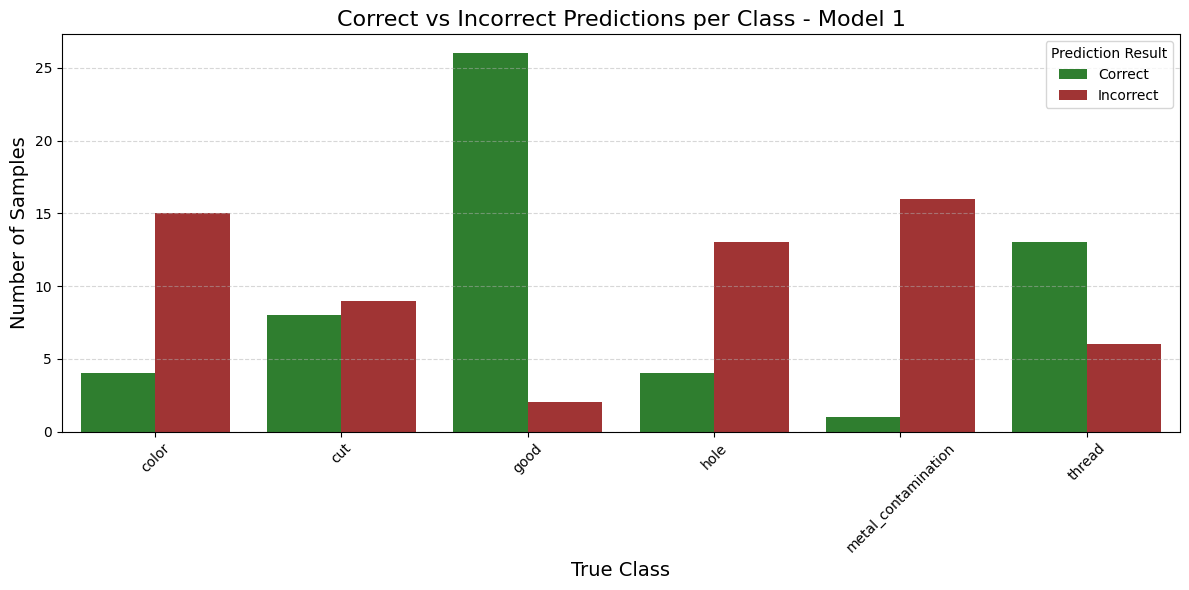

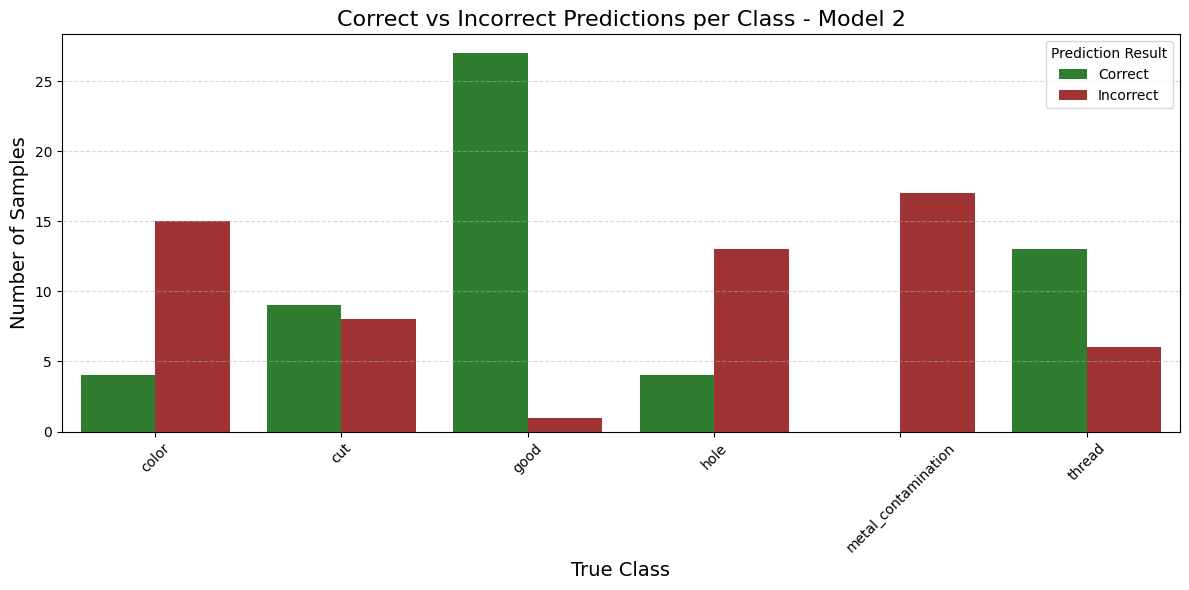

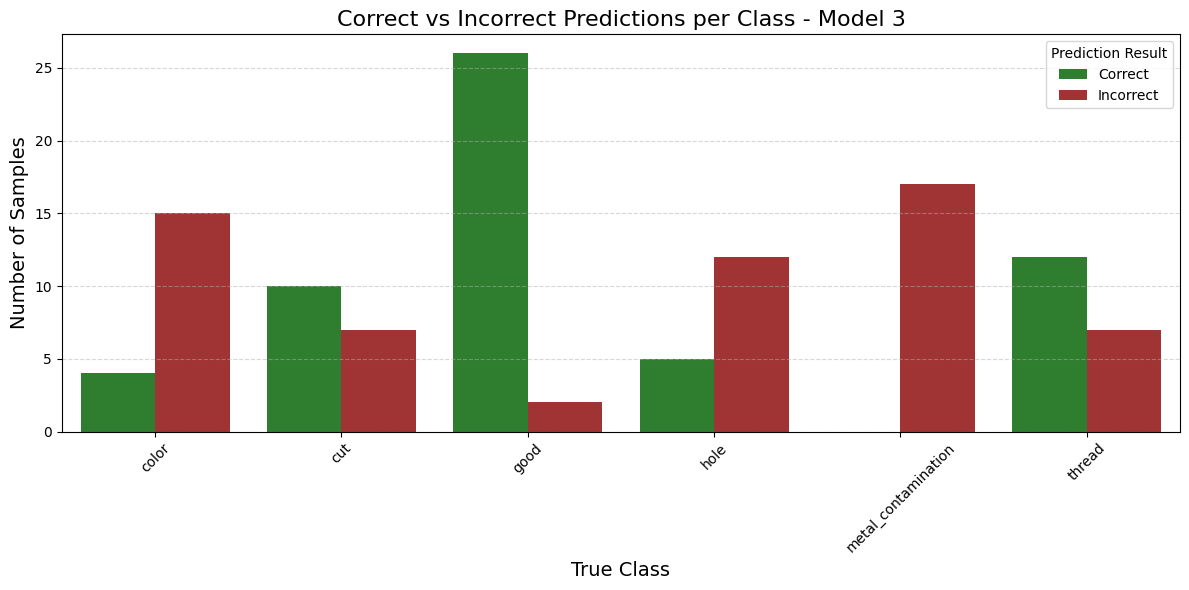

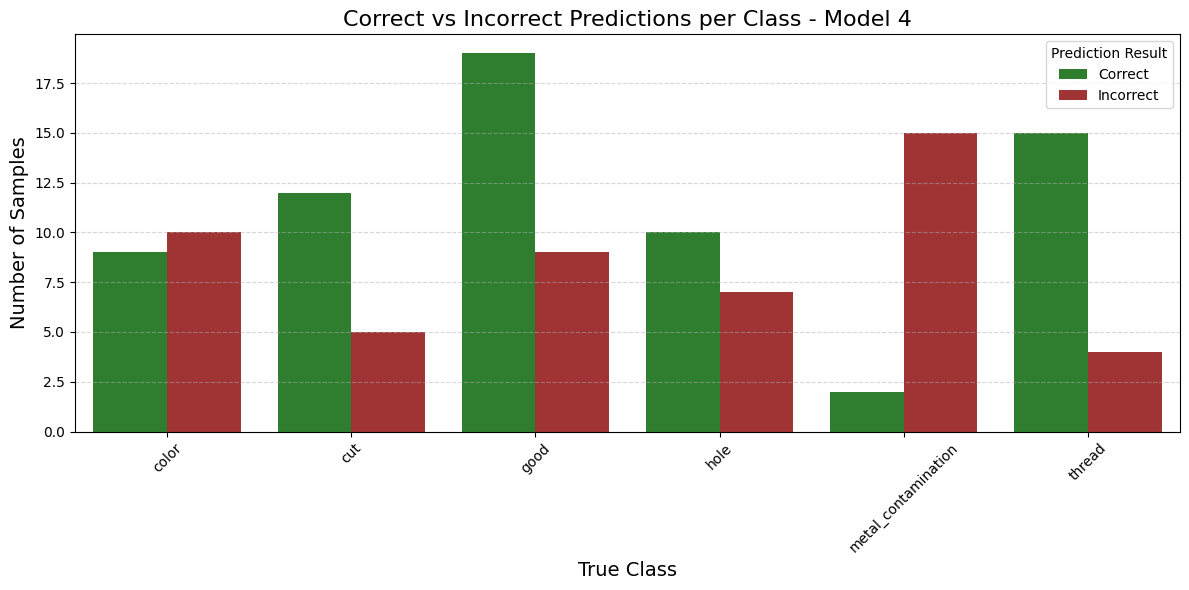

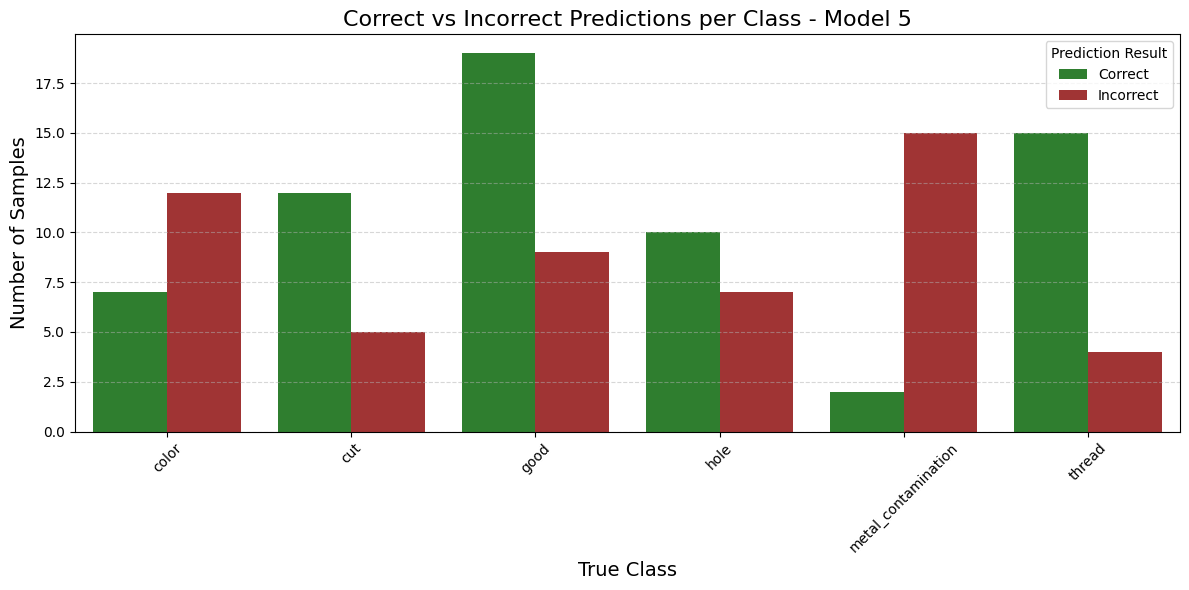

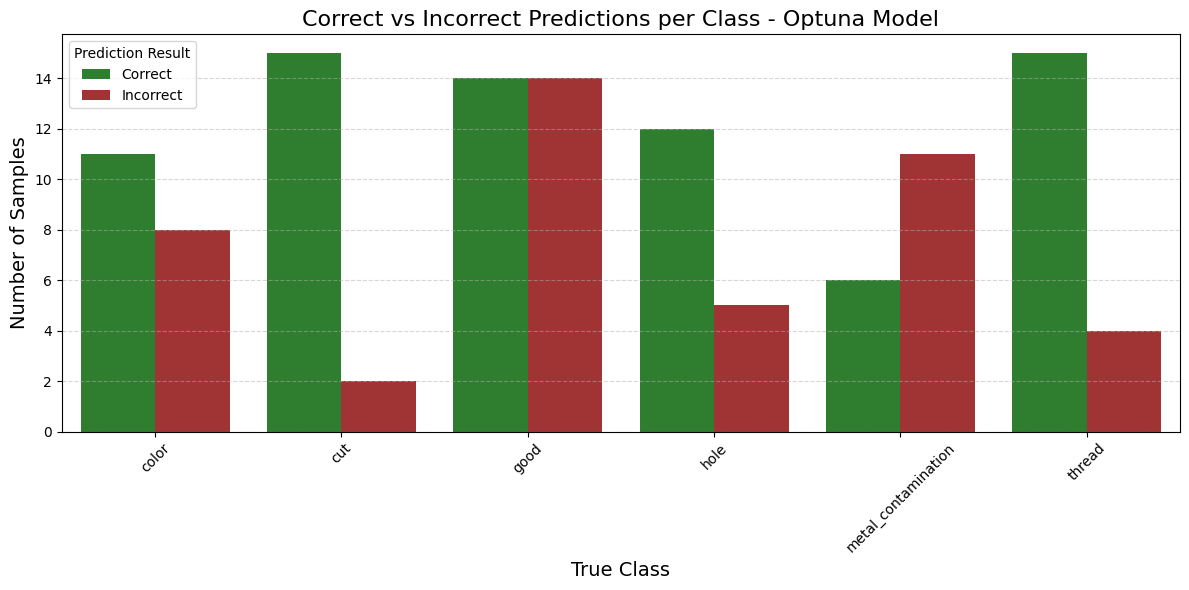

In [23]:
# Plot Correct and Incorrect Scores per Model
# Define normal and anomalous classes
normal_classes = ['good']
anomalous_classes = ['color', 'cut', 'hole', 'metal_contamination', 'thread']

for idx, row in carpet_results_df2.iterrows():
    model_name = row['Model']
    scores = row['Scores']
    
    # Since scores = –decision_function,
    #  scores ≥ 0  means decision_function ≤ 0 ⇒ anomaly
    #  scores <  0  means decision_function >  0 ⇒ normal
    preds = np.array([-1 if s >= 0 else 1 for s in scores])
    
    # Build results DataFrame
    model_results = pd.DataFrame({
        'Image_Path': img_paths,
        'True_Class': [os.path.basename(os.path.dirname(p)) for p in img_paths],
        'Prediction': preds
    })

    # Map true labels
    model_results['True_Label'] = model_results['True_Class'].apply(
        lambda x: 1 if x in normal_classes else -1
    )

    # Determine correctness
    model_results['Correct'] = model_results['Prediction'] == model_results['True_Label']
    model_results['Correct_Label'] = model_results['Correct'].map({True: 'Correct', False: 'Incorrect'})

    grouped_counts = model_results.groupby(['True_Class', 'Correct_Label']).size().reset_index(name='Count')

    plt.figure(figsize=(12, 6))
    sns.barplot(data=grouped_counts, x='True_Class', y='Count', hue='Correct_Label', palette=['forestgreen','firebrick'])
    plt.title(f'Correct vs Incorrect Predictions per Class - {model_name}', fontsize=16)
    plt.xlabel('True Class', fontsize=14)
    plt.ylabel('Number of Samples', fontsize=14)
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.legend(title='Prediction Result')
    plt.tight_layout()
    plt.show()


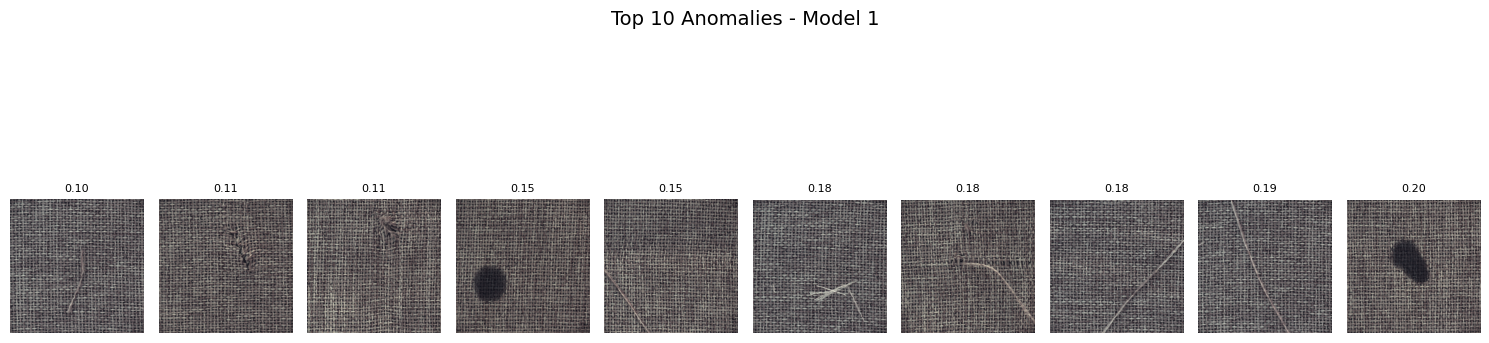

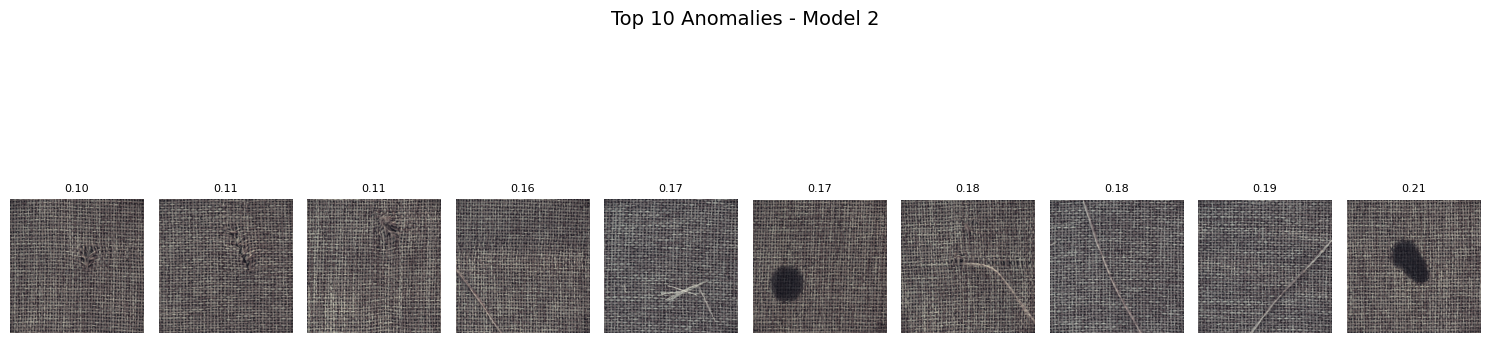

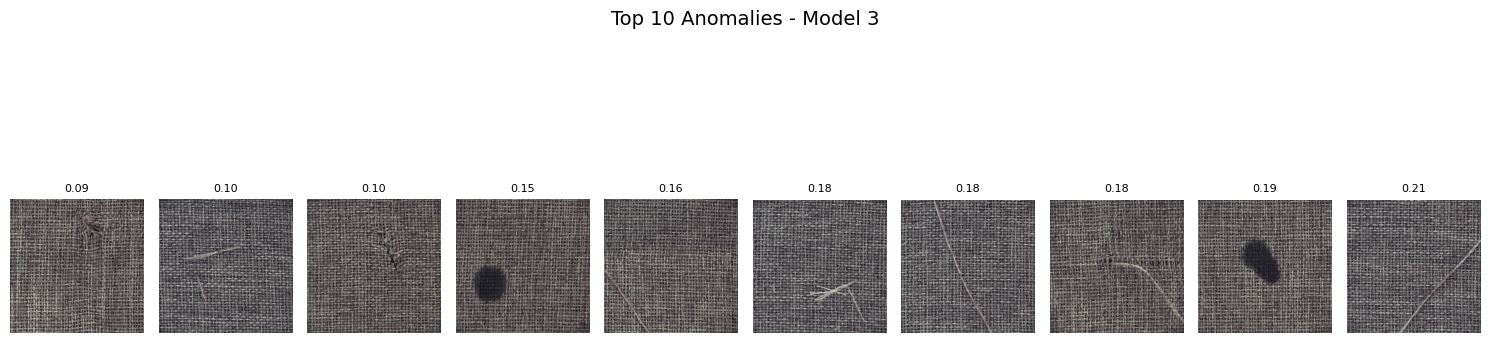

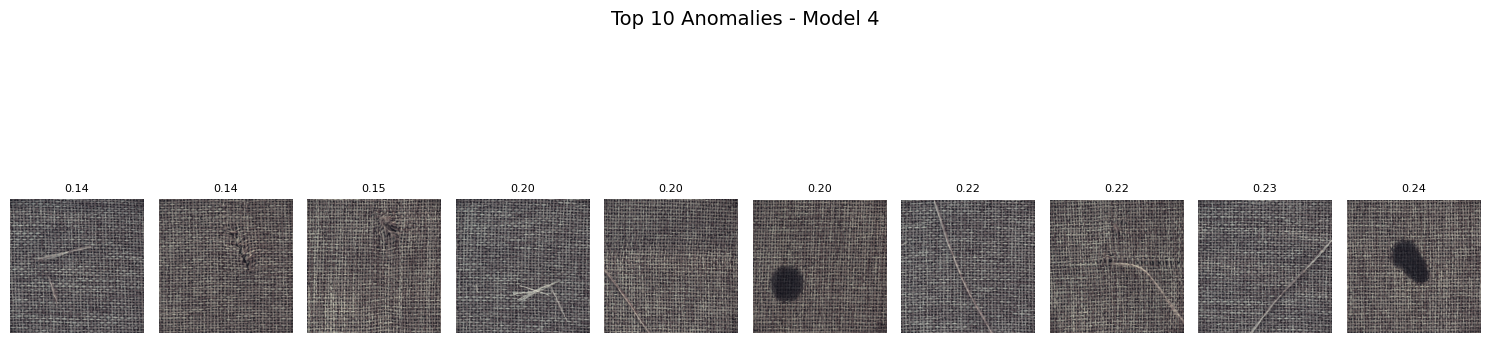

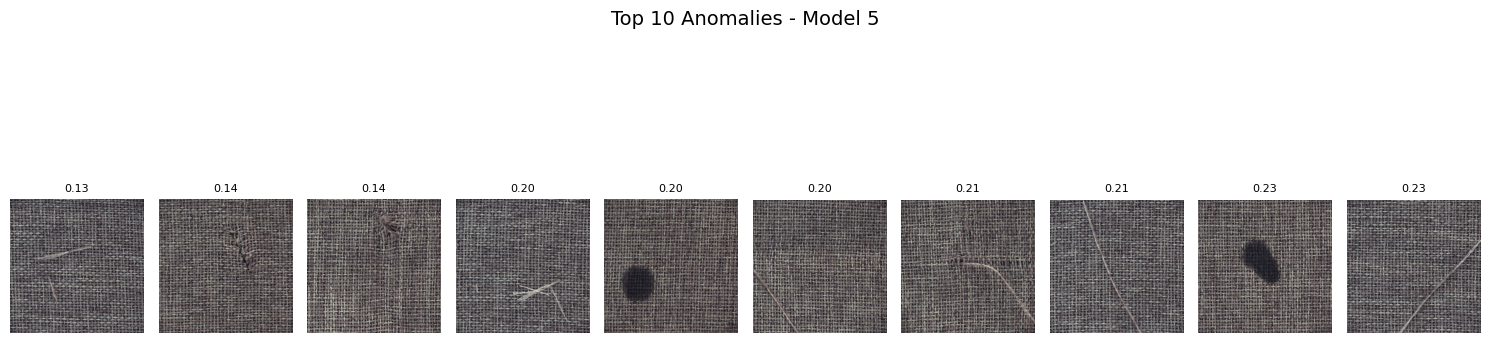

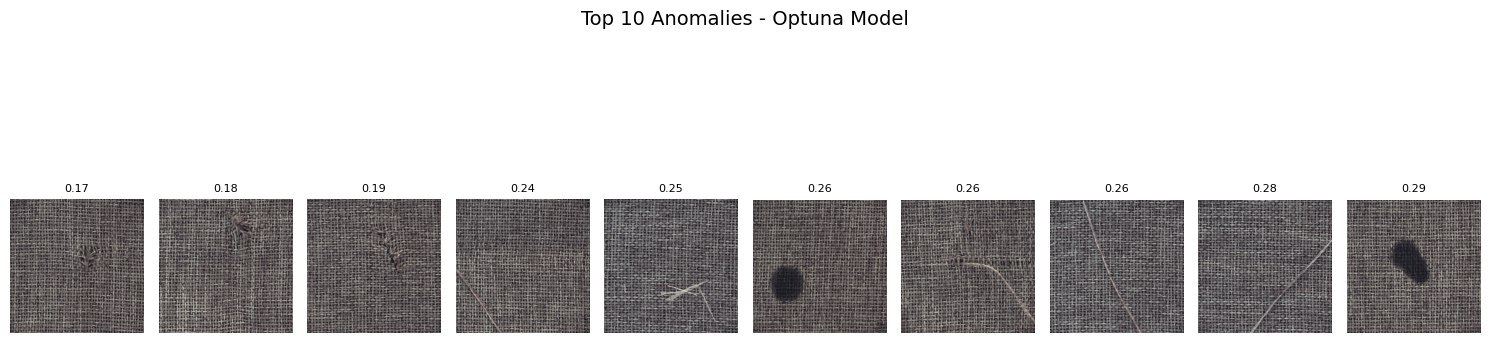

In [24]:
# Plot the Top Anomalies per Model
def plot_top_anomalies(model_name, scores, image_paths, top_n=10):

    # Get indices of the highest scores (most anomalous)
    top_indices = np.argsort(scores)[-top_n:]
    top_images = [image_paths[i] for i in top_indices]
    top_scores = [scores[i] for i in top_indices]

    plt.figure(figsize=(15, 5))
    for idx, (img_path, score) in enumerate(zip(top_images, top_scores)):
        img = Image.open(img_path)
        plt.subplot(1, top_n, idx + 1)
        plt.imshow(img)
        plt.title(f"{score:.2f}", fontsize=8)
        plt.axis("off")
    plt.suptitle(f"Top {top_n} Anomalies - {model_name}", fontsize=14)
    plt.tight_layout()
    plt.show()

# Loop over all evaluated models in results dataframe
for idx, row in carpet_results_df2.iterrows():
    model_name = row['Model']
    scores = row['Scores']
    
    plot_top_anomalies(model_name, scores, img_paths, top_n=10)


**Key Takeaways for Carpet Dataset:**
1) More balanced anomaly detection performance​
- The model has achieved an improved balance between detecting anomalies and avoiding false positives, with an F1 Score of 0.73.
- It correctly identified more anomalies than before, reaching a recall of 0.66, although some true anomalies were still missed (less than half of the total true anomalies).
- At the same time, a precision of 0.81 indicates the model occasionally misclassified normal images as defective, showing a trade-off in achieving better recall.

2) Greater misclassifications due to a more challenging image dataset​
- The carpet dataset introduced more visual complexity, which made it harder for the model to clearly separate normal and anomalous patterns.
- Many defects in this dataset—such as texture irregularities or minor visual distortions—were subtle or inconsistently expressed, increasing both false negatives and false positives.

3) Faster isolation for Thread, Cut, Color defects​
- These types of defects exhibited strong and distinct deviations from the normal image patterns, making them easier for Isolation Forest to detect early in the tree-building process.
- In contrast, Hole and Metal Contamination defects were more difficult to isolate due to their subtle visual features, contributing to lower recall on these cases.